# Pristupni rad iz Osnova ekonometrije

**Prezime i ime:** Petar Belko  
**Matični broj:** 0066299238  
**Akademska godina:** 2025./2026.  
**Kategorija izdataka:** GASO  

## Struktura notebooka
- **I dio:** konstrukcija varijable i deskriptivna analiza
- **II dio:** regresijska analiza i dijagnostički testovi (Zadaci 1-9)
- **III dio:** stacionarnost, ADF, adekvatan model i VAR analiza (Zadaci 10-14)

Svi izračuni temelje se na datoteci `demand.xlsx`.


In [1]:
# Import necessary libraries
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Učitavanje podataka
data_path = 'demand.xlsx'
df = pd.read_excel(data_path)

# Čišćenje podataka - zadržavamo samo potrebne stupce
cols_to_keep = ['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']
df = df[cols_to_keep]

print("=== Stupci nakon čišćenja ===")
print(df.columns.tolist())
print("\nPrvih 5 redova:")
print(df.head())

=== Stupci nakon čišćenja ===
['gaso', 'pgaso', 'dpi', 'ptpe', 'pop', 'time']

Prvih 5 redova:
        gaso   pgaso     dpi    ptpe     pop  time
0  60.744761  18.576  1715.5  20.432  177130     1
1  62.825049  19.112  1759.7  20.767  180760     2
2  63.473382  18.924  1819.2  20.985  183742     3
3  66.165106  19.043  1908.2  21.232  186590     4
4  68.197955  18.997  1979.1  21.479  189300     5


## I DIO
### Definicija varijable relativne cijene

Kreira se varijabla **PRGASO** prema zadanoj formuli:

$$
PRGASO_t = 100 \cdot \frac{PGASO_t}{PTPE_t}
$$

Varijabla mjeri relativnu cijenu kategorije GASO u odnosu na opći indeks cijena.


In [2]:
# Kreiranje Indeksa relativnih cijena
df['prgaso'] = 100 * (df['pgaso'] / df['ptpe'])
print("\nPrvih 5 redova:")
print(df.head(5)[['prgaso']])


Prvih 5 redova:
      prgaso
0  90.916210
1  92.030626
2  90.178699
3  89.690090
4  88.444527


### Deskriptivna analiza varijable GASO

Prikazuju se osnovni pokazatelji distribucije:
- aritmetička sredina
- medijan
- standardna devijacija
- asimetrija
- spljoštenost

Uz numerički prikaz daje se i histogram s procjenom gustoće.


=== Deskriptivni pokazatelji za GASO ===

1. Aritmetička sredina: 122.0260
   → Prosječna potrošnja benzina iznosi 122.0260 jedinica.

2. Medijan: 120.6637
   → Polovica promatranja ima potrošnju manju od 120.6637 jedinica.

3. Asimetrija (α₃): -0.0791
   → Distribucija je negativno asimetrična (rep je s lijeve strane).

4. Spljoštenost (α₄): -0.8297
   → Distribucija je plosnatija od normalne.

5. Standardna devijacija: 35.1763
   → Potrošnja benzina u prosjeku odstupa 35.1763 jedinica od aritmetičke sredine.


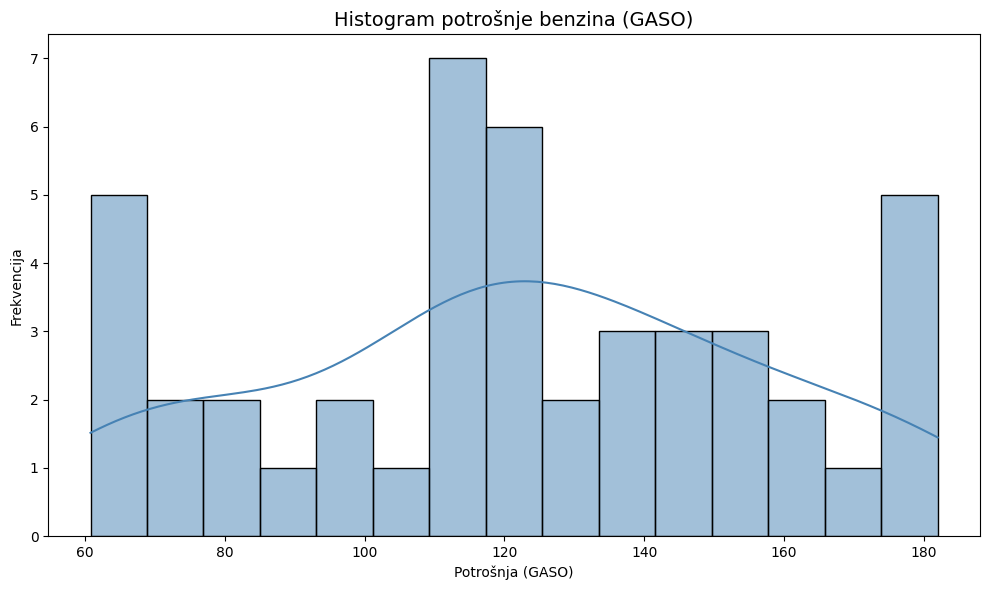

In [3]:
# Deskriptivni pokazatelji za GASO
print("=== Deskriptivni pokazatelji za GASO ===\n")

mean = df['gaso'].mean()
median = df['gaso'].median()
std = df['gaso'].std()
skew = df['gaso'].skew()
kurt = df['gaso'].kurtosis()

print(f"1. Aritmetička sredina: {mean:.4f}")
print(f"   → Prosječna potrošnja benzina iznosi {mean:.4f} jedinica.\n")

print(f"2. Medijan: {median:.4f}")
print(f"   → Polovica promatranja ima potrošnju manju od {median:.4f} jedinica.\n")

print(f"3. Asimetrija (α₃): {skew:.4f}")
if skew > 0:
    print(f"   → Distribucija je pozitivno asimetrična (rep je s desne strane).\n")
elif skew < 0:
    print(f"   → Distribucija je negativno asimetrična (rep je s lijeve strane).\n")
else:
    print(f"   → Distribucija je simetrična.\n")

print(f"4. Spljoštenost (α₄): {kurt:.4f}")
if kurt > 0:
    print(f"   → Distribucija je šiljatija od normalne.\n")
elif kurt < 0:
    print(f"   → Distribucija je plosnatija od normalne.\n")
else:
    print(f"   → Distribucija ima normalnu spljoštenost.\n")

print(f"5. Standardna devijacija: {std:.4f}")
print(f"   → Potrošnja benzina u prosjeku odstupa {std:.4f} jedinica od aritmetičke sredine.")

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['gaso'], kde=True, color='steelblue', bins=15)
plt.title('Histogram potrošnje benzina (GASO)', fontsize=14)
plt.xlabel('Potrošnja (GASO)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()

## II DIO
### Zadatak 1 - Višestruka linearna regresija (log-model)

Procjenjuje se model:

$$
\log(GASO_t) = \beta_0 + \beta_1\log(DPI_t) + \beta_2\log(PRGASO_t) + \varepsilon_t
$$

Provode se:
- skupni **F-test** značajnosti modela
- pojedinačni jednosmjerni **t-testovi** za `log(DPI)` i `log(PRGASO)`.


In [4]:
# Kreiranje log varijabli
for col in ['gaso', 'dpi', 'prgaso']:
    df[f'log_{col}'] = np.log(df[col])

# Definiranje zavisne i nezavisnih varijabli
y = df['log_gaso']
X = sm.add_constant(df[['log_dpi', 'log_prgaso']])

# Procjena modela
model = sm.OLS(y, X).fit()
print(model.summary())

b0 = model.params['const']
b1 = model.params['log_dpi']
b2 = model.params['log_prgaso']

print('')
print('=== Procijenjena regresijska jednadžba ===')
print(f"log(GASO) = {b0:.4f} + {b1:.4f}*log(DPI) + {b2:.4f}*log(PRGASO)")

print('')
print('=== Interpretacija koeficijenta uz log(PRGASO) ===')
smjer = 'smanjuje' if b2 < 0 else 'povećava'
print(
    f"Koeficijent uz log(PRGASO) iznosi {b2:.4f}. "
    f"Uz ostale varijable nepromijenjene, porast relativne cijene za 1% {smjer} "
    f"potrošnju benzina za približno {abs(b2):.4f}% (elastičnost cijene)."
)

print('')
print('=== Skupni F-test ===')
print('H₀: β₁ = β₂ = 0')
print('H₁: barem jedan β_i ≠ 0')
print(f"F-statistika: {model.fvalue:.4f}")
print(f"p-vrijednost: {model.f_pvalue:.6f}")
print('-> Odbacujemo H₀.' if model.f_pvalue < 0.05 else '-> Ne odbacujemo H₀.')


def one_sided_pvalue(t_stat, p_two_sided, alternative):
    if alternative == 'greater':
        return p_two_sided / 2 if t_stat > 0 else 1 - p_two_sided / 2
    if alternative == 'less':
        return p_two_sided / 2 if t_stat < 0 else 1 - p_two_sided / 2
    raise ValueError("alternative mora biti 'greater' ili 'less'")

print('')
print('=== Pojedinačni jednosmjerni t-testovi ===')

# Test za log(DPI): H₁: β₁ > 0
t_dpi = model.tvalues['log_dpi']
p_dpi = one_sided_pvalue(t_dpi, model.pvalues['log_dpi'], 'greater')
print('')
print('log(DPI): H₀: β₁ = 0, H₁: β₁ > 0')
print(f"t = {t_dpi:.4f}, p(jednosmjerni) = {p_dpi:.6f}")
print('-> Odbacujemo H₀.' if p_dpi < 0.05 else '-> Ne odbacujemo H₀.')

# Test za log(PRGASO): H₁: β₂ < 0
t_prgaso = model.tvalues['log_prgaso']
p_prgaso = one_sided_pvalue(t_prgaso, model.pvalues['log_prgaso'], 'less')
print('')
print('log(PRGASO): H₀: β₂ = 0, H₁: β₂ < 0')
print(f"t = {t_prgaso:.4f}, p(jednosmjerni) = {p_prgaso:.6f}")
print('-> Odbacujemo H₀.' if p_prgaso < 0.05 else '-> Ne odbacujemo H₀.')


                            OLS Regression Results                            
Dep. Variable:               log_gaso   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     730.4
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           2.36e-33
Time:                        12:23:07   Log-Likelihood:                 69.130
No. Observations:                  45   AIC:                            -132.3
Df Residuals:                      42   BIC:                            -126.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8568      0.281     -3.051      0.0

### Zadatak 2 - Analiza reziduala

Provjera reziduala modela iz Zadatka 1:
- graf reziduala kroz vrijeme
- Q-Q dijagram
- Jarque-Bera test normalnosti
- osnovna procjena autokoreliranosti/stacionarnosti reziduala.


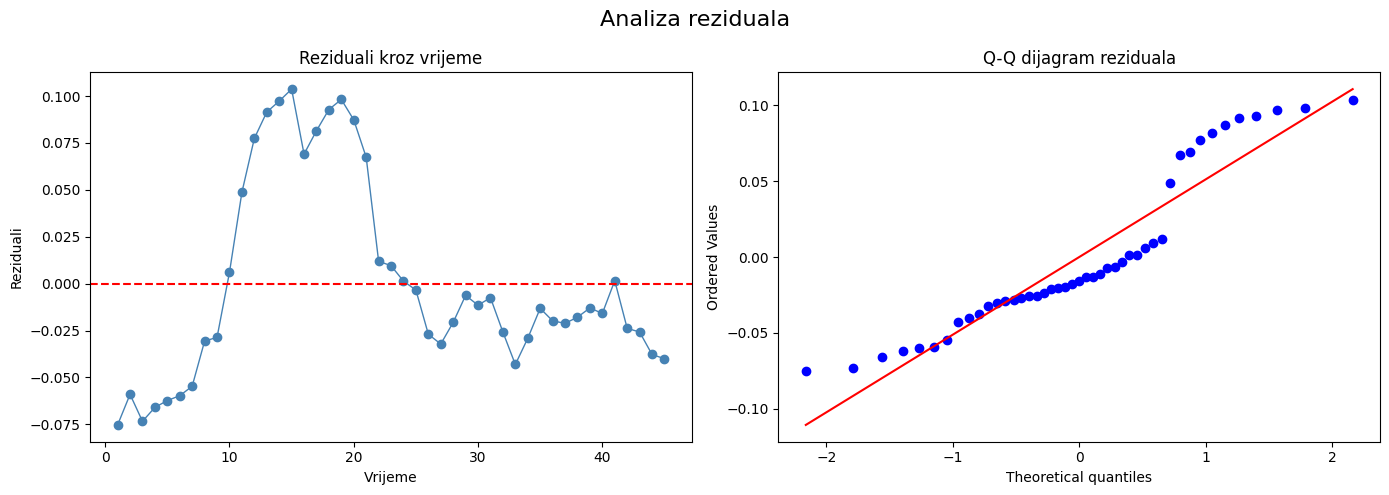

=== Rezime reziduala ===
Srednja vrijednost reziduala: -0.000000
Standardna devijacija: 0.0527
Autokorelacija reziduala (lag 1): 0.9423

=== Jarque-Bera test normalnosti ===
H₀: reziduali su normalno distribuirani
H₁: reziduali nisu normalno distribuirani
JB = 4.7863, p = 0.0913
-> Ne odbacujemo H₀.

=== Kratka interpretacija ===
Reziduali pokazuju jaku serijsku povezanost (autokorelaciju),
što je važniji problem od same normalnosti za OLS inferenciju.
Normalnost reziduala nije odbačena na 5%.


In [5]:
# Dohvaćanje reziduala
residuals = model.resid
fitted = model.fittedvalues

# 1) Grafička analiza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analiza reziduala', fontsize=16)

axes[0].plot(df['time'], residuals, marker='o', color='steelblue', linewidth=1)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Reziduali kroz vrijeme')
axes[0].set_xlabel('Vrijeme')
axes[0].set_ylabel('Reziduali')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q dijagram reziduala')

plt.tight_layout()
plt.show()

# 2) Test normalnosti
jb_stat, jb_p = stats.jarque_bera(residuals)
acf1 = residuals.autocorr(lag=1)

print('=== Rezime reziduala ===')
print(f"Srednja vrijednost reziduala: {residuals.mean():.6f}")
print(f"Standardna devijacija: {residuals.std():.4f}")
print(f"Autokorelacija reziduala (lag 1): {acf1:.4f}")

print('')
print('=== Jarque-Bera test normalnosti ===')
print('H₀: reziduali su normalno distribuirani')
print('H₁: reziduali nisu normalno distribuirani')
print(f"JB = {jb_stat:.4f}, p = {jb_p:.4f}")
print('-> Odbacujemo H₀.' if jb_p < 0.05 else '-> Ne odbacujemo H₀.')

print('')
print('=== Kratka interpretacija ===')
if abs(acf1) > 0.3:
    print('Reziduali pokazuju jaku serijsku povezanost (autokorelaciju),')
    print('što je važniji problem od same normalnosti za OLS inferenciju.')
else:
    print('Nema izražene autokorelacije reziduala po prvom lagu.')

if jb_p < 0.05:
    print('Distribucija reziduala odstupa od normalne; t/F zaključke treba tumačiti oprezno.')
else:
    print('Normalnost reziduala nije odbačena na 5%.')


### Zadatak 3 - Intervalna procjena parametra

Određuje se 95%-tni interval pouzdanosti za koeficijent uz `log(PRGASO)` i daje se ekonomska interpretacija.


In [6]:

# ============================================================
# INTERVALNA PROCJENA ZA log(PRGASO)
# ============================================================
conf_int = model.conf_int(alpha=0.05)

lb = conf_int.loc['log_prgaso', 0]
ub = conf_int.loc['log_prgaso', 1]

print("=== 95%-tni interval procjene za koeficijent uz log(PRGASO) ===\n")
print(f"Donja granica: {lb:.4f}")
print(f"Gornja granica: {ub:.4f}")
print(f"\nInterval: [{lb:.4f}, {ub:.4f}]")

print("\n=== Interpretacija ===")
print(f"S 95%-tnom pouzdanošću možemo tvrditi da se pravi koeficijent")
print(f"elastičnosti potražnje za benzinom s obzirom na relativnu cijenu")
print(f"nalazi u intervalu [{lb:.4f}, {ub:.4f}].")

contains_zero = lb < 0 < ub
if contains_zero:
    print(f"\nBudući da interval sadrži nulu, koeficijent NIJE statistički")
    print(f"značajan na razini značajnosti od 5%.")
    print(f"\nInterval prelazi nulu (donja granica je negativna, gornja pozitivna),")
    print(f"stoga ne možemo sa 95%-tnom pouzdanošću zaključiti o smjeru utjecaja")
    print(f"relativne cijene benzina na potrošnju.")
else:
    print(f"\nBudući da interval ne sadrži nulu, koeficijent je statistički")
    print(f"značajan na razini značajnosti od 5%.")
    if ub < 0:
        print(f"\nOba ruba intervala su negativna, što potvrđuje očekivani")
        print(f"negativan odnos između relativne cijene i potrošnje benzina —")
        print(f"porast relativne cijene benzina za 1% smanjuje potrošnju")
        print(f"između {abs(ub):.4f}% i {abs(lb):.4f}%.")
    else:
        print(f"\nOba ruba intervala su pozitivna, što upućuje na pozitivan")
        print(f"odnos između relativne cijene i potrošnje benzina —")
        print(f"porast relativne cijene benzina za 1% povećava potrošnju")
        print(f"između {abs(lb):.4f}% i {abs(ub):.4f}%.")


=== 95%-tni interval procjene za koeficijent uz log(PRGASO) ===

Donja granica: -0.1607
Gornja granica: 0.0555

Interval: [-0.1607, 0.0555]

=== Interpretacija ===
S 95%-tnom pouzdanošću možemo tvrditi da se pravi koeficijent
elastičnosti potražnje za benzinom s obzirom na relativnu cijenu
nalazi u intervalu [-0.1607, 0.0555].

Budući da interval sadrži nulu, koeficijent NIJE statistički
značajan na razini značajnosti od 5%.

Interval prelazi nulu (donja granica je negativna, gornja pozitivna),
stoga ne možemo sa 95%-tnom pouzdanošću zaključiti o smjeru utjecaja
relativne cijene benzina na potrošnju.


### Zadatak 4 - Usporedba utjecaja regresora

U log-log modelu koeficijenti su elastičnosti, pa se utjecaji `log(DPI)` i `log(PRGASO)` izravno uspoređuju po:
- apsolutnoj veličini koeficijenta
- statističkoj značajnosti.


In [7]:

# ============================================================
# KOJA VARIJABLA VIŠE UTJEČE NA POTROŠNJU BENZINA
# ============================================================
# Napomena o odabiru modela:
# Koristimo log-log (dvostruko-logaritamski) OLS model jer su sve
# varijable transformirane logaritmom, pa su procijenjeni koeficijenti
# izravno interpretirani kao elastičnosti koje se
# mogu međusobno uspoređivati bez dodatne standardizacije.

b1_abs = abs(model.params['log_dpi'])
b2_abs = abs(model.params['log_prgaso'])

print("=== Usporedba utjecaja varijabli na log(GASO) ===\n")
print(f"Koeficijent uz log(DPI)    (elastičnost dohotka):  {model.params['log_dpi']:.4f}")
print(f"  |β₁| = {b1_abs:.4f}  |  t = {model.tvalues['log_dpi']:.4f}  |  "
      f"p (dvostrani) = {model.pvalues['log_dpi']:.4f}")

print(f"\nKoeficijent uz log(PRGASO) (elastičnost cijene):  {model.params['log_prgaso']:.4f}")
print(f"  |β₂| = {b2_abs:.4f}  |  t = {model.tvalues['log_prgaso']:.4f}  |  "
      f"p (dvostrani) = {model.pvalues['log_prgaso']:.4f}")

print("\n=== Zaključak ===")
print(f"Budući da je model log-log, oba koeficijenta predstavljaju elastičnosti")
print(f"i izravno su usporedivi po apsolutnoj vrijednosti.\n")
print(f"  |β₁(DPI)|    = {b1_abs:.4f}  (statistički značajan, p ≈ 0.000)")
print(f"  |β₂(PRGASO)| = {b2_abs:.4f}  (statistički NEznačajan, p = {model.pvalues['log_prgaso']:.4f})\n")

if b1_abs > b2_abs:
    print("→ Osobni dohodak (DPI) ima VEĆI utjecaj na potrošnju benzina od relativne cijene.")
    print(f"  Porast dohotka za 1% prosječno povećava potrošnju benzina za {b1_abs:.4f}%,")
    print(f"  dok je elastičnost prema relativnoj cijeni ({model.params['log_prgaso']:.4f}) zanemariva")
    print(f"  i statistički nije različita od nule na razini značajnosti od 5%.")
else:
    print("→ Relativna cijena (PRGASO) ima VEĆI utjecaj na potrošnju benzina od osobnog dohotka.")


=== Usporedba utjecaja varijabli na log(GASO) ===

Koeficijent uz log(DPI)    (elastičnost dohotka):  0.7085
  |β₁| = 0.7085  |  t = 38.2065  |  p (dvostrani) = 0.0000

Koeficijent uz log(PRGASO) (elastičnost cijene):  -0.0526
  |β₂| = 0.0526  |  t = -0.9826  |  p (dvostrani) = 0.3314

=== Zaključak ===
Budući da je model log-log, oba koeficijenta predstavljaju elastičnosti
i izravno su usporedivi po apsolutnoj vrijednosti.

  |β₁(DPI)|    = 0.7085  (statistički značajan, p ≈ 0.000)
  |β₂(PRGASO)| = 0.0526  (statistički NEznačajan, p = 0.3314)

→ Osobni dohodak (DPI) ima VEĆI utjecaj na potrošnju benzina od relativne cijene.
  Porast dohotka za 1% prosječno povećava potrošnju benzina za 0.7085%,
  dok je elastičnost prema relativnoj cijeni (-0.0526) zanemariva
  i statistički nije različita od nule na razini značajnosti od 5%.


### Zadatak 5 - Testiranje restrikcije na parametre

Testira se hipoteza da je utjecaj dohotka dvostruko veći od utjecaja relativne cijene (u apsolutnoj vrijednosti):

$$
H_0: \beta_1 + 2\beta_2 = 0
$$

na razini značajnosti od 1%.


In [8]:

import scipy.stats as stats
import numpy as np

# ============================================================
# TESTIRANJE: Je li β₁ = 2·|β₂|  (tj. β₁ + 2·β₂ = 0)
# ============================================================

# --- 1. FORMULACIJA HIPOTEZE ---
print("=== 1. Formulacija hipoteze ===\n")
print("Model: log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + ε")
print()
print("Budući da su oba koeficijenta elastičnosti (log-log model), pitanje")
print("'je li DPI dvostruko veći utjecaj od PRGASO' formalizira se kao:")
print()
print("  H₀: β₁ = 2·|β₂|")
print("  Kako je β₂ < 0, vrijedi |β₂| = −β₂, pa:")
print("  H₀: β₁ = −2·β₂   ⟺   β₁ + 2·β₂ = 0")
print("  H₁: β₁ + 2·β₂ ≠ 0   (dvostrani test)")
print()
print("  Razina značajnosti: α = 1% = 0.01")

# --- 2. TEST VELIČINA I POSTUPAK ---
print("\n=== 2. Test veličina i postupak testiranja ===\n")
print()
print("Test veličina:")
print("            β̂₁ + 2·β̂₂")
print("  t = ─────────────────────────────────────────────────")
print("      √[Var(β̂₁) + 4·Var(β̂₂) + 4·Cov(β̂₁, β̂₂)]")
print()
print("Pod H₀, t ~ t(n − k − 1) = t(42).")
print()
print("Odbacujemo H₀ ako |t| > t_{α/2, 42}  (dvostrana kritična vrijednost).")

# --- 3. IZRAČUN RUČNO ---
print("\n=== 3. Ručni izračun test veličine ===\n")

b1_hat = model.params['log_dpi']
b2_hat = model.params['log_prgaso']
cov_matrix = model.cov_params()

var_b1 = cov_matrix.loc['log_dpi', 'log_dpi']
var_b2 = cov_matrix.loc['log_prgaso', 'log_prgaso']
cov_b1_b2 = cov_matrix.loc['log_dpi', 'log_prgaso']

linear_combo = b1_hat + 2 * b2_hat
se_combo = np.sqrt(var_b1 + 4 * var_b2 + 4 * cov_b1_b2)
t_stat = linear_combo / se_combo
df_resid = int(model.df_resid)

print(f"  β̂₁                      = {b1_hat:.6f}")
print(f"  β̂₂                      = {b2_hat:.6f}")
print(f"  β̂₁ + 2·β̂₂              = {linear_combo:.6f}")
print(f"  Var(β̂₁)                 = {var_b1:.8f}")
print(f"  Var(β̂₂)                 = {var_b2:.8f}")
print(f"  Cov(β̂₁, β̂₂)            = {cov_b1_b2:.8f}")
print(f"  SE(β̂₁ + 2·β̂₂)          = {se_combo:.6f}")
print(f"  t-statistika             = {t_stat:.4f}")

# --- 4. PROVJERA PUTEM statsmodels t_test ---
print("\n=== 4. Provjera – statsmodels t_test ===\n")
# R vektor: 0·const + 1·log_dpi + 2·log_prgaso = 0
restriction = "log_dpi + 2*log_prgaso = 0"
t_test_result = model.t_test(restriction)
print(t_test_result)

# --- 5. KRITIČNA VRIJEDNOST I ODLUKA ---
print("\n=== 5. Kritična vrijednost i odluka ===\n")
alpha = 0.01
t_crit = stats.t.ppf(1 - alpha / 2, df=df_resid)
p_value = float(t_test_result.pvalue)

print(f"  Razina značajnosti α = {alpha} (1%)")
print(f"  Stupnjevi slobode    = {df_resid}")
print(f"  Kritična vrijednost  t_{{0.005, {df_resid}}} = ±{t_crit:.4f}")
print(f"  |t-statistika|       = {abs(t_stat):.4f}")
print(f"  p-vrijednost (dvostrana) = {p_value:.4f}")
print()
if abs(t_stat) > t_crit:
    print(f"  |{abs(t_stat):.4f}| > {t_crit:.4f}  →  ODBACUJEMO H₀")
else:
    print(f"  |{abs(t_stat):.4f}| ≤ {t_crit:.4f}  →  NE ODBACUJEMO H₀")

# --- 6. INTERPRETACIJA ---
print("\n=== 6. Interpretacija zaključka ===\n")
if abs(t_stat) > t_crit:
    print("Na razini značajnosti od 1%, odbacujemo hipotezu da je elastičnost")
    print("potražnje za benzinom s obzirom na dohodak dvostruko veća (po")
    print("apsolutnoj vrijednosti) od elastičnosti s obzirom na relativnu cijenu.")
    print(f"Procijenjene elastičnosti (β̂₁ = {b1_hat:.4f}, β̂₂ = {b2_hat:.4f})")
    print("statistički se značajno razlikuju od odnosa 2:1.")
else:
    print("Na razini značajnosti od 1%, ne odbacujemo hipotezu da je elastičnost")
    print("potražnje za benzinom s obzirom na dohodak dvostruko veća (po")
    print("apsolutnoj vrijednosti) od elastičnosti s obzirom na relativnu cijenu.")
    print(f"Podatci su konzistentni s ograničenjem β₁ + 2·β₂ = 0")
    print(f"(β̂₁ = {b1_hat:.4f}, β̂₂ = {b2_hat:.4f}).")


=== 1. Formulacija hipoteze ===

Model: log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + ε

Budući da su oba koeficijenta elastičnosti (log-log model), pitanje
'je li DPI dvostruko veći utjecaj od PRGASO' formalizira se kao:

  H₀: β₁ = 2·|β₂|
  Kako je β₂ < 0, vrijedi |β₂| = −β₂, pa:
  H₀: β₁ = −2·β₂   ⟺   β₁ + 2·β₂ = 0
  H₁: β₁ + 2·β₂ ≠ 0   (dvostrani test)

  Razina značajnosti: α = 1% = 0.01

=== 2. Test veličina i postupak testiranja ===


Test veličina:
            β̂₁ + 2·β̂₂
  t = ─────────────────────────────────────────────────
      √[Var(β̂₁) + 4·Var(β̂₂) + 4·Cov(β̂₁, β̂₂)]

Pod H₀, t ~ t(n − k − 1) = t(42).

Odbacujemo H₀ ako |t| > t_{α/2, 42}  (dvostrana kritična vrijednost).

=== 3. Ručni izračun test veličine ===

  β̂₁                      = 0.708460
  β̂₂                      = -0.052638
  β̂₁ + 2·β̂₂              = 0.603183
  Var(β̂₁)                 = 0.00034384
  Var(β̂₂)                 = 0.00286971
  Cov(β̂₁, β̂₂)            = -0.00005223
  SE(β̂₁ + 2·β̂₂)        

### Zadatak 6 - Multikolinearnost

Analiza uključuje:
- korelacijsku matricu (`TIME`, `log(DPI)`, `log(PRGASO)`)
- usporedbu modela s/bez trenda
- Kleinov kriterij
- VIF pokazatelje
- pomoćnu regresiju za izračun VIF-a varijable `log(PRGASO)`.


In [9]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# PRIPREMA VARIJABLI
# ============================================================
df['log_gaso']   = np.log(df['gaso'])
df['log_dpi']    = np.log(df['dpi'])
df['log_prgaso'] = np.log(df['prgaso'])
# TIME je već u df['time'] kao 1..n

# ============================================================
# KORELACIJSKA MATRICA: TIME, log(DPI), log(PRGASO)
# ============================================================
print("=" * 65)
print("1. KORELACIJSKA MATRICA: TIME, log(DPI), log(PRGASO)")
print("=" * 65)

corr_vars = df[['time', 'log_dpi', 'log_prgaso']]
corr_matrix = corr_vars.corr()
print(corr_matrix.to_string())

# ============================================================
# REGRESIJA S TRENDOM: log(GASO) ~ log(DPI) + log(PRGASO) + TIME
# ============================================================
print("\n" + "=" * 65)
print("2. REGRESIJA S TRENDOM")
print("   log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + β₃·TIME + ε")
print("=" * 65)

y_t   = df['log_gaso']
X_t   = sm.add_constant(df[['log_dpi', 'log_prgaso', 'time']])
model_t = sm.OLS(y_t, X_t).fit()
print(model_t.summary())

# ============================================================
# INTERPRETACIJA KOEFICIJENTA UZ TIME
# ============================================================
b3 = model_t.params['time']
print("\n=== Interpretacija koeficijenta uz TIME ===\n")
print(f"Koeficijent uz TIME (β̂₃) = {b3:.6f}")
print(f"Porast vremena za jednu vremensku jedinicu (1 kvartal), uz nepromijenjene")
print(f"ostale varijable, mijenja potrošnju benzina prosječno za ≈ {b3 * 100:.4f}%.")
if b3 > 0:
    print(f"Trend je POZITIVAN: potrošnja benzina raste s vremenom.")
else:
    print(f"Trend je NEGATIVAN: potrošnja benzina pada s vremenom.")

# ============================================================
# JEDNOSMJERNI T-TEST ZA TIME (H₁: β₃ < 0)
# ============================================================
print("\n=== Jednosmjerni t-test za TIME ===")
print("H₀: β₃ = 0")
print("H₁: β₃ < 0  (negativan vremenski trend potrošnje benzina)")
t_time   = model_t.tvalues['time']
p_time_2 = model_t.pvalues['time']
# Jednosmjerni p za H₁: β₃ < 0 — t je negativan, p = p_dvostrani / 2
p_time_1 = p_time_2 / 2 if t_time < 0 else 1 - p_time_2 / 2
df_t     = int(model_t.df_resid)
t_crit_5 = stats.t.ppf(0.95, df=df_t)  # negativna kritična vrijednost: -t_crit_5
print(f"t-statistika: {t_time:.4f}")
print(f"p-vrijednost (jednosmjerni): {p_time_1:.4f}")
print(f"Kritična vrijednost −t_{{0.05, {df_t}}} = −{t_crit_5:.4f}")
if p_time_1 < 0.05:
    print("→ Odbacujemo H₀. TIME je statistički značajan na razini 5%.")
else:
    print("→ Ne odbacujemo H₀. TIME nije statistički značajan na razini 5%.")

# ============================================================
# USPOREDBA MODELA: s TIME vs. bez TIME (Zadatak 1)
# ============================================================
print("\n" + "=" * 65)
print("3. USPOREDBA: MODEL BEZ TIME (Zadatak 1) vs. MODEL S TIME")
print("=" * 65)

y0 = df['log_gaso']
X0 = sm.add_constant(df[['log_dpi', 'log_prgaso']])
model0 = sm.OLS(y0, X0).fit()

header = f"{'Veličina':<30} {'Bez TIME':>12} {'S TIME':>12}"
print(header)
print("-" * len(header))
print(f"{'R²':<30} {model0.rsquared:>12.4f} {model_t.rsquared:>12.4f}")
print(f"{'Adj. R²':<30} {model0.rsquared_adj:>12.4f} {model_t.rsquared_adj:>12.4f}")
print(f"{'AIC':<30} {model0.aic:>12.4f} {model_t.aic:>12.4f}")
print(f"{'β̂(log_dpi)':<30} {model0.params['log_dpi']:>12.4f} {model_t.params['log_dpi']:>12.4f}")
print(f"{'SE(log_dpi)':<30} {model0.bse['log_dpi']:>12.4f} {model_t.bse['log_dpi']:>12.4f}")
print(f"{'β̂(log_prgaso)':<30} {model0.params['log_prgaso']:>12.4f} {model_t.params['log_prgaso']:>12.4f}")
print(f"{'SE(log_prgaso)':<30} {model0.bse['log_prgaso']:>12.4f} {model_t.bse['log_prgaso']:>12.4f}")
print()
print("Ako dodavanje TIME-a značajno povećava SE koeficijenata → sign multikolinearnosti.")

# ============================================================
# 4. KLEINOV KRITERIJ
# ============================================================
print("\n" + "=" * 65)
print("4. KLEINOV KRITERIJ MULTIKOLINEARNOSTI")
print("=" * 65)
print("Kriterij: multikolinearnost je problematična ako je r(xᵢ,xⱼ)²")
print("veći od R² punog modela (s TIME).\n")

R2_full = model_t.rsquared
print(f"R² punog modela (s TIME): {R2_full:.4f}\n")

pairs = [
    ('time',       'log_dpi',    'TIME vs log(DPI)'),
    ('time',       'log_prgaso', 'TIME vs log(PRGASO)'),
    ('log_dpi',    'log_prgaso', 'log(DPI) vs log(PRGASO)'),
]
print(f"{'Par varijabli':<28} {'r':>8} {'r²':>8} {'r² > R²?':>10}")
print("-" * 58)
for v1, v2, label in pairs:
    r = df[[v1, v2]].corr().iloc[0, 1]
    r2 = r ** 2
    flag = "DA ⚠" if r2 > R2_full else "Ne"
    print(f"{label:<28} {r:>8.4f} {r2:>8.4f} {flag:>10}")

print(f"\nZaključak po Kleinovom kriteriju:")
klein_violations = [(l, df[[v1,v2]].corr().iloc[0,1]**2)
                    for v1,v2,l in pairs
                    if df[[v1,v2]].corr().iloc[0,1]**2 > R2_full]
if klein_violations:
    for l, r2 in klein_violations:
        print(f"  Par '{l}': r² = {r2:.4f} > R² = {R2_full:.4f} → MULTIKOLINEARNOST")
else:
    print("  Niti jedan par ne zadovoljava Kleinov kriterij (r² ≤ R²).")
    print("  Prema Kleinu, multikolinearnost nije ozbiljan problem.")

# ============================================================
# 5. VIF POKAZATELJI
# ============================================================
print("\n" + "=" * 65)
print("5. VIF POKAZATELJI (Variance Inflation Factor)")
print("=" * 65)
print("VIF(xⱼ) = 1 / (1 − Rⱼ²), gdje je Rⱼ² R² iz regresije xⱼ")
print("na sve ostale regresore. VIF > 10 upozorava na multikolinearnost.\n")

X_vif = df[['log_dpi', 'log_prgaso', 'time']].copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Varijabla'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i+1)
                   for i in range(X_vif.shape[1])]
vif_data['Problem?'] = vif_data['VIF'].apply(lambda v: 'DA ⚠' if v > 10 else 'Ne')
print(vif_data.to_string(index=False))

# ============================================================
# 6. IZRAČUN VIF ZA log(PRGASO) – POMOĆNA REGRESIJA
# ============================================================
print("\n" + "=" * 65)
print("6. IZRAČUN VIF ZA log(PRGASO) — POMOĆNA REGRESIJA")
print("=" * 65)
print("Regresijska jednadžba:")
print("  log(PRGASO) = α₀ + α₁·log(DPI) + α₂·TIME + ν\n")

y_aux = df['log_prgaso']
X_aux = sm.add_constant(df[['log_dpi', 'time']])
model_aux = sm.OLS(y_aux, X_aux).fit()
print(model_aux.summary())


1. KORELACIJSKA MATRICA: TIME, log(DPI), log(PRGASO)
                time   log_dpi  log_prgaso
time        1.000000  0.994499    0.031951
log_dpi     0.994499  1.000000    0.052578
log_prgaso  0.031951  0.052578    1.000000

2. REGRESIJA S TRENDOM
   log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + β₃·TIME + ε
                            OLS Regression Results                            
Dep. Variable:               log_gaso   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     1229.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           3.66e-40
Time:                        12:23:08   Log-Likelihood:                 90.107
No. Observations:                  45   AIC:                            -172.2
Df Residuals:                      41   BIC:                            -165.0
Df Model:                           3                   

### Zadatak 7 - Autokorelacija

Provodi se:
- jednosmjerni Durbin-Watson test za autokorelaciju 1. reda
- Breusch-Godfrey LM test za autokorelaciju do 2. reda.


In [10]:

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
import scipy.stats as stats

# ============================================================
# a) DURBIN-WATSON TEST — AUTOKORELACIJA PRVOG REDA
# ============================================================

print("=" * 65)
print("a) DURBIN-WATSON TEST — AUTOKORELACIJA PRVOG REDA")
print("=" * 65)

print("""
Model (Zadatak 1): log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + εₜ

Pretpostavljamo AR(1) strukturu pogreške:
  εₜ = ρ·εₜ₋₁ + uₜ,  uₜ ~ N(0, σ²)

--- Hipoteze (jednosmjerni test, H₁: pozitivna autokorelacija) ---
  H₀: ρ = 0  (nema autokorelacije prvog reda)
  H₁: ρ > 0  (postoji pozitivna autokorelacija prvog reda)
  Razina značajnosti: α = 5%
""")

# DW statistika
dw = durbin_watson(model.resid)

# Kritične vrijednosti iz DW tablica: n=45, k'=2, α=0.05
n_obs = int(model.nobs)
k_reg = 2        # broj regresora bez konstante
dL = 1.430
dU = 1.615

print(f"--- Test veličina ---")
print(f"DW statistika:")
print(f"         Σ(êₜ - êₜ₋₁)²")
print(f"  d = ─────────────────  =  {dw:.4f}")
print(f"           Σêₜ²")
print()
print(f"--- Kritične vrijednosti (n={n_obs}, k'={k_reg}, α=5%) ---")
print(f"  dL = {dL}   dU = {dU}")
print(f"  Zona odbacivanja H₀:     d < dL  (pozitivna autokorelacija)")
print(f"  Zona neodlučnosti:  dL ≤ d ≤ dU")
print(f"  Zona prihvaćanja H₀:     d > dU")
print()
print(f"--- Postupak testiranja ---")
print(f"  d = {dw:.4f}")
if dw < dL:
    print(f"  {dw:.4f} < dL = {dL}  →  d se nalazi u zoni ODBACIVANJA H₀")
    conclusion_dw = "ODBACUJEMO"
elif dw <= dU:
    print(f"  dL = {dL} ≤ {dw:.4f} ≤ dU = {dU}  →  zona NEODLUČNOSTI")
    conclusion_dw = "NEODLUČNO"
else:
    print(f"  {dw:.4f} > dU = {dU}  →  d se nalazi u zoni PRIHVAĆANJA H₀")
    conclusion_dw = "NE ODBACUJEMO"

print()
print(f"--- Zaključak ---")
if conclusion_dw == "ODBACUJEMO":
    print(f"Na razini značajnosti od 5%, ODBACUJEMO H₀.")
    print(f"Postoji statistički značajna POZITIVNA autokorelacija prvog reda")
    print(f"u rezidualima modela (d = {dw:.4f} << dL = {dL}).")
    print(f"Vrijednost DW statistike bliska nuli ukazuje na izrazito jaku")
    print(f"pozitivnu autokorelaciju (ρ ≈ 1 − d/2 ≈ {1 - dw/2:.3f}).")
    print(f"Posljedice: OLS procjenitelji su nepristrani ali neučinkoviti;")
    print(f"standardne greške su potcijenjene → t i F testovi su nepouzdani.")
elif conclusion_dw == "NE ODBACUJEMO":
    print(f"Na razini značajnosti od 5%, NE ODBACUJEMO H₀.")
    print(f"Nema statističkih dokaza o autokorelaciji prvog reda (d = {dw:.4f}).")
else:
    print(f"Test je NEODLUČAN (d = {dw:.4f} u zoni [{dL}, {dU}]).")
    print(f"Ne možemo donijeti pouzdanu odluku o autokorelaciji.")

# ============================================================
# b) LM TEST — AUTOKORELACIJA DRUGOG REDA (Breusch-Godfrey)
# ============================================================

print()
print("=" * 65)
print("b) BREUSCH-GODFREY LM TEST — AUTOKORELACIJA DRUGOG REDA")
print("=" * 65)

print("""
Pretpostavljamo AR(2) strukturu pogreške:
  εₜ = ρ₁·εₜ₋₁ + ρ₂·εₜ₋₂ + uₜ

--- Hipoteze ---
  H₀: ρ₁ = ρ₂ = 0  (nema autokorelacije do reda 2)
  H₁: ρ₁ ≠ 0 ili/i ρ₂ ≠ 0  (postoji autokorelacija reda ≤ 2)
  Razina značajnosti: α = 5%
""")

print("--- Postupak LM testa ---")
print("1. Procijeni originalni model → dobij rezidualne êₜ")
print("2. Regresija êₜ na originalne regresore + êₜ₋₁ + êₜ₋₂")
print("   → dobij R²_aux iz te pomoćne regresije")
print("3. Test veličina: LM = (n − p)·R²_aux ~ χ²(p) pod H₀")
print("   gdje je p = 2 (red autokorelacije)")
print()

lm_stat, lm_p, f_stat, f_p = acorr_breusch_godfrey(model, nlags=2)
chi2_crit = stats.chi2.ppf(0.95, df=2)
n_eff = n_obs - 2  # n - p

print(f"--- Rezultati ---")
print(f"  LM statistika  = (n−p)·R²_aux = {lm_stat:.4f}")
print(f"  p-vrijednost (χ²)              = {lm_p:.4f}")
print(f"  Kritična vrijednost χ²(2; 0.05) = {chi2_crit:.4f}")
print()
print(f"--- Odluka ---")
if lm_stat > chi2_crit:
    print(f"  {lm_stat:.4f} > {chi2_crit:.4f}  →  ODBACUJEMO H₀")
else:
    print(f"  {lm_stat:.4f} ≤ {chi2_crit:.4f}  →  NE ODBACUJEMO H₀")

print()
print(f"--- Zaključak ---")
if lm_stat > chi2_crit:
    print(f"Na razini značajnosti od 5%, ODBACUJEMO H₀.")
    print(f"LM = {lm_stat:.4f} >> χ²(2; 0.05) = {chi2_crit:.4f} (p ≈ {lm_p:.4f}).")
    print(f"Postoji statistički značajna autokorelacija drugog reda.")
    print(f"Ovaj rezultat konzistentan je s DW testom: izrazito niska DW")
    print(f"vrijednost ({dw:.4f}) upućuje na jaku autokorelaciju koja se")
    print(f"proteže i na više redove.")
else:
    print(f"Na razini značajnosti od 5%, NE ODBACUJEMO H₀.")
    print(f"Nema statističkih dokaza o autokorelaciji drugog reda.")


a) DURBIN-WATSON TEST — AUTOKORELACIJA PRVOG REDA

Model (Zadatak 1): log(GASO) = β₀ + β₁·log(DPI) + β₂·log(PRGASO) + εₜ

Pretpostavljamo AR(1) strukturu pogreške:
  εₜ = ρ·εₜ₋₁ + uₜ,  uₜ ~ N(0, σ²)

--- Hipoteze (jednosmjerni test, H₁: pozitivna autokorelacija) ---
  H₀: ρ = 0  (nema autokorelacije prvog reda)
  H₁: ρ > 0  (postoji pozitivna autokorelacija prvog reda)
  Razina značajnosti: α = 5%

--- Test veličina ---
DW statistika:
         Σ(êₜ - êₜ₋₁)²
  d = ─────────────────  =  0.1124
           Σêₜ²

--- Kritične vrijednosti (n=45, k'=2, α=5%) ---
  dL = 1.43   dU = 1.615
  Zona odbacivanja H₀:     d < dL  (pozitivna autokorelacija)
  Zona neodlučnosti:  dL ≤ d ≤ dU
  Zona prihvaćanja H₀:     d > dU

--- Postupak testiranja ---
  d = 0.1124
  0.1124 < dL = 1.43  →  d se nalazi u zoni ODBACIVANJA H₀

--- Zaključak ---
Na razini značajnosti od 5%, ODBACUJEMO H₀.
Postoji statistički značajna POZITIVNA autokorelacija prvog reda
u rezidualima modela (d = 0.1124 << dL = 1.43).
Vrijed

### Zadatak 8 - Heteroskedastičnost

Provodi se Whiteov test heteroskedastičnosti uz formalne hipoteze i pomoćnu jednadžbu. Ako se heteroskedastičnost potvrdi, primjenjuje se HAC (Newey-West) korekcija standardnih pogrešaka.


In [11]:
from statsmodels.stats.diagnostic import het_white
import scipy.stats as stats

print('=' * 65)
print('WHITEOV TEST HETEROSKEDASTIČNOSTI')
print('Model: log(GASO) = b0 + b1*log(DPI) + b2*log(PRGASO) + e_t')
print('=' * 65)

print('Pomoćna regresija: e_t^2 na regresore, njihove kvadrate i međusobni produkt.')
print('H₀: homoskedastičnost | H₁: heteroskedastičnost')

lm_w, lm_p_w, f_w, f_p_w = het_white(model.resid, X)
p_white = 5
alpha_1 = 0.01
alpha_5 = 0.05
chi2_crit_1pct = stats.chi2.ppf(1 - alpha_1, df=p_white)
chi2_crit_5pct = stats.chi2.ppf(1 - alpha_5, df=p_white)
n_obs_w = int(model.nobs)
R2_white = lm_w / n_obs_w

reject_1pct = lm_w > chi2_crit_1pct
reject_5pct = lm_w > chi2_crit_5pct
heterosk = reject_5pct

print('Rezultati testa:')
print(f"  n = {n_obs_w}")
print(f"  R2_aux = {R2_white:.4f}")
print(f"  LM = {lm_w:.4f}")
print(f"  p-vrijednost (LM) = {lm_p_w:.6f}")
print(f"  chi2(5; 1%) = {chi2_crit_1pct:.4f}")
print(f"  chi2(5; 5%) = {chi2_crit_5pct:.4f}")

if reject_1pct:
    print('')
    print('Odluka: odbacujemo H₀ na 1% (i na 5%).')
elif reject_5pct:
    print('')
    print('Odluka: ne odbacujemo H₀ na 1%, ali odbacujemo na 5%.')
else:
    print('')
    print('Odluka: ne odbacujemo H₀ ni na 5%.')

if heterosk:
    print('')
    print('Prisutna je heteroskedastičnost, pa koristimo HAC robusne standardne pogreške.')

    n_hac = int(model.nobs)
    maxlags = int(4 * (n_hac / 100) ** (2 / 9))
    model_hac = model.get_robustcov_results(cov_type='HAC', maxlags=maxlags, use_correction=True)

    print(model_hac.summary())

    print('')
    print('=== Usporedba OLS i HAC standardnih pogrešaka ===')
    hdr = f"{'Varijabla':<14} {'b':>8} | {'OLS SE':>8} {'OLS p':>8} | {'HAC SE':>8} {'HAC p':>8}"
    print(hdr)
    print('-' * len(hdr))

    names = list(model.params.index)
    for i, nm in enumerate(names):
        print(
            f"{nm:<14} {model.params[nm]:>8.4f} | {model.bse[nm]:>8.4f} {model.pvalues[nm]:>8.4f} | "
            f"{model_hac.bse[i]:>8.4f} {model_hac.pvalues[i]:>8.4f}"
        )
else:
    print('')
    print('Nema dovoljno dokaza o heteroskedastičnosti na razini 5%.')


WHITEOV TEST HETEROSKEDASTIČNOSTI
Model: log(GASO) = b0 + b1*log(DPI) + b2*log(PRGASO) + e_t
Pomoćna regresija: e_t^2 na regresore, njihove kvadrate i međusobni produkt.
H₀: homoskedastičnost | H₁: heteroskedastičnost
Rezultati testa:
  n = 45
  R2_aux = 0.3878
  LM = 17.4503
  p-vrijednost (LM) = 0.003720
  chi2(5; 1%) = 15.0863
  chi2(5; 5%) = 11.0705

Odluka: odbacujemo H₀ na 1% (i na 5%).

Prisutna je heteroskedastičnost, pa koristimo HAC robusne standardne pogreške.
                            OLS Regression Results                            
Dep. Variable:               log_gaso   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     298.1
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.53e-25
Time:                        12:23:08   Log-Likelihood:                 69.130
No. Observations:                  45   AIC:      

### Zadatak 9 - Pristranost zbog izostavljene varijable (OVB)

Uspoređuju se tri modela:
1. `log(GASO)` na `log(DPI)` i `log(PRGASO)`
2. `log(GASO)` samo na `log(DPI)`
3. `log(GASO)` samo na `log(PRGASO)`

Analizira se smjer i veličina pristranosti prema teorijskim OVB formulama.


In [12]:

# ============================================================
# PRISTRANOST ZBOG IZOSTAVLJENE VARIJABLE (Omitted Variable Bias)
# ============================================================

print("=" * 70)
print("PRISTRANOST ZBOG IZOSTAVLJENE VARIJABLE")
print("=" * 70)

# ---- Procjena sva tri modela ----
y_ovb = df['log_gaso']

m1 = sm.OLS(y_ovb, sm.add_constant(df[['log_dpi', 'log_prgaso']])).fit()
m2 = sm.OLS(y_ovb, sm.add_constant(df[['log_dpi']])).fit()
m3 = sm.OLS(y_ovb, sm.add_constant(df[['log_prgaso']])).fit()

b1_full = m1.params['log_dpi']
b2_full = m1.params['log_prgaso']

# ---- Pomoćne regresije za delta koeficijente ----
delta_prgaso_given_dpi = sm.OLS(df['log_prgaso'],
    sm.add_constant(df[['log_dpi']])).fit().params['log_dpi']
delta_dpi_given_prgaso = sm.OLS(df['log_dpi'],
    sm.add_constant(df[['log_prgaso']])).fit().params['log_prgaso']

# ============================================================
# TEORIJA PRISTRANOSTI
# ============================================================
print("""
Teorija (omitted variable bias):
─────────────────────────────────
Točan model: log(GASO) = β0 + β1·log(DPI) + β2·log(PRGASO) + ε

Ako izostavimo X2 = log(PRGASO) i regresiramo samo na X1 = log(DPI):
  E[β̂1_pristrani] = β1 + β2 · δ21
  gdje je δ21 = koef. iz regresije log(PRGASO) na log(DPI)
  Smjer pristranosti ovisi o znaku(β2) × znaku(δ21)

Ako izostavimo X1 = log(DPI) i regresiramo samo na X2 = log(PRGASO):
  E[β̂2_pristrani] = β2 + β1 · δ12
  gdje je δ12 = koef. iz regresije log(DPI) na log(PRGASO)
  Smjer pristranosti ovisi o znaku(β1) × znaku(δ12)
""")

# ============================================================
# ANALIZA SMJERA PRISTRANOSTI
# ============================================================
print("=" * 70)
print("ANALIZA SMJERA PRISTRANOSTI")
print("=" * 70)

print("\n--- Model 2: izostavljamo log(PRGASO) ---")
bias2 = b2_full * delta_prgaso_given_dpi
print("  delta21 = koef(log_prgaso | log_dpi) = %.4f  [mali, pozitivan]" % delta_prgaso_given_dpi)
print("  β2 = %.4f  [negativan]" % b2_full)
print("  Pristranost = β2 · δ21 = %.4f × %.4f = %.6f" % (b2_full, delta_prgaso_given_dpi, bias2))
print("  Predznak: (neg) × (poz) = NEGATIVAN → β̂1 je NEGATIVNO pristran (blago potcijenjen)")
print("  Teorijski β̂1_M2 = %.4f + (%.6f) = %.4f" % (b1_full, bias2, b1_full + bias2))
print("  Stvarni  β̂1_M2 = %.4f  ✓" % m2.params['log_dpi'])

print("\n--- Model 3: izostavljamo log(DPI) ---")
bias3 = b1_full * delta_dpi_given_prgaso
print("  delta12 = koef(log_dpi | log_prgaso) = %.4f  [pozitivan]" % delta_dpi_given_prgaso)
print("  β1 = %.4f  [pozitivan]" % b1_full)
print("  Pristranost = β1 · δ12 = %.4f × %.4f = %.4f" % (b1_full, delta_dpi_given_prgaso, bias3))
print("  Predznak: (poz) × (poz) = POZITIVAN → β̂2 je POZITIVNO pristran (precjenjen)")
print("  Teorijski β̂2_M3 = %.4f + %.4f = %.4f" % (b2_full, bias3, b2_full + bias3))
print("  Stvarni  β̂2_M3 = %.4f  ✓" % m3.params['log_prgaso'])

# ============================================================
# TABLICA USPOREDBE
# ============================================================
print()
print("=" * 70)
print("USPOREDNA TABLICA KOEFICIJENATA")
print("=" * 70)

dpi_m2    = m2.params['log_dpi']
prgaso_m3 = m3.params['log_prgaso']

col1, col2, col3 = "log(DPI)", "log(PRGASO)", "R²"
print()
print("%-48s  %10s  %13s  %6s" % ("Model", col1, col2, col3))
print("-" * 82)
print("%-48s  %10.4f  %13.4f  %6.4f" % (
    "Model 1 – log(GASO) na log(DPI) i log(PRGASO)",
    b1_full, b2_full, m1.rsquared))
print("%-48s  %10.4f  %13s  %6.4f" % (
    "Model 2 – log(GASO) samo na log(DPI)",
    dpi_m2, "—", m2.rsquared))
print("%-48s  %10s  %13.4f  %6.4f" % (
    "Model 3 – log(GASO) samo na log(PRGASO)",
    "—", prgaso_m3, m3.rsquared))
print()

# ============================================================
# ZAKLJUČAK
# ============================================================
print("=" * 70)
print("ZAKLJUČAK")
print("=" * 70)
print("""
Model 2 (izostavljamo log(PRGASO)):
  Pristranost je NEGATIVNA ali ZANEMARIVA (%.6f).
  Razlog: log(DPI) i log(PRGASO) su gotovo ortogonalni (r ≈ 0.053),
  pa izostavljanje log(PRGASO) gotovo uopće ne utječe na β̂1.
  Promjena: %.4f → %.4f (razlika od samo %.4f).

Model 3 (izostavljamo log(DPI)):
  Pristranost je POZITIVNA i VELIKA (+%.4f).
  Razlog: log(DPI) objašnjava gotovo svu varijancu log(GASO) (R²=%.4f).
  Izostavljanjem tog dominantnog regresora, varijabla log(PRGASO)
  "preuzima" dio njegovog utjecaja putem korelacije.
  Koeficijent uz log(PRGASO) mijenja PREDZNAK: %.4f → +%.4f
  — model čak pokazuje krivi smjer utjecaja relativne cijene!
  R² pada s %.4f na samo %.4f.
""" % (
    bias2,
    b1_full, dpi_m2, abs(b1_full - dpi_m2),
    bias3,
    m1.rsquared,
    b2_full, prgaso_m3,
    m1.rsquared, m3.rsquared
))


PRISTRANOST ZBOG IZOSTAVLJENE VARIJABLE

Teorija (omitted variable bias):
─────────────────────────────────
Točan model: log(GASO) = β0 + β1·log(DPI) + β2·log(PRGASO) + ε

Ako izostavimo X2 = log(PRGASO) i regresiramo samo na X1 = log(DPI):
  E[β̂1_pristrani] = β1 + β2 · δ21
  gdje je δ21 = koef. iz regresije log(PRGASO) na log(DPI)
  Smjer pristranosti ovisi o znaku(β2) × znaku(δ21)

Ako izostavimo X1 = log(DPI) i regresiramo samo na X2 = log(PRGASO):
  E[β̂2_pristrani] = β2 + β1 · δ12
  gdje je δ12 = koef. iz regresije log(DPI) na log(PRGASO)
  Smjer pristranosti ovisi o znaku(β1) × znaku(δ12)

ANALIZA SMJERA PRISTRANOSTI

--- Model 2: izostavljamo log(PRGASO) ---
  delta21 = koef(log_prgaso | log_dpi) = 0.0182  [mali, pozitivan]
  β2 = -0.0526  [negativan]
  Pristranost = β2 · δ21 = -0.0526 × 0.0182 = -0.000958
  Predznak: (neg) × (poz) = NEGATIVAN → β̂1 je NEGATIVNO pristran (blago potcijenjen)
  Teorijski β̂1_M2 = 0.7085 + (-0.000958) = 0.7075
  Stvarni  β̂1_M2 = 0.7075  ✓

--- Mo

## III DIO


### Zadatak 10 - Stacionarnost i korelogram reziduala

**Stacionarnost u širem smislu** znači da su kroz vrijeme stabilni:
- očekivanje: $E(Y_t)=\mu$
- varijanca: $Var(Y_t)=\sigma^2$
- autokovarijanca: $Cov(Y_t, Y_{t-k})=\gamma_k$ ovisi samo o lagu $k$.

U ovom zadatku se na rezidualima iz Zadatka 1 analiziraju:
- ACF/PACF korelogram
- Ljung-Box test do uključivo 4. reda.

Ljung-Box statistika:

$$
Q^* = n(n+2)\sum_{k=1}^{m}\frac{\hat{\rho}_k^2}{n-k}, \quad m=4
$$


b) KORELOGRAM REZIDUALA - ZADATAK 1


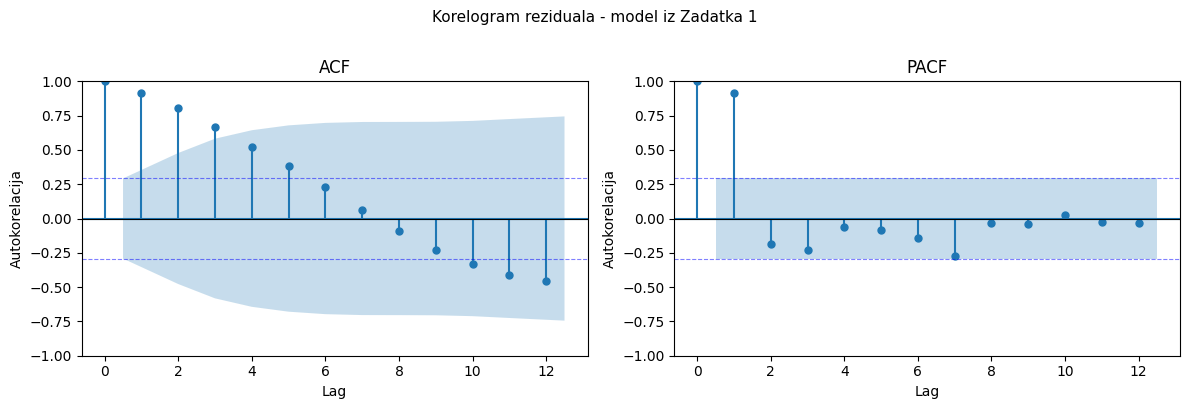

Granica signifikantnosti (+/-1.96/sqrt(n)): +/-0.2922
 Lag       ACF     |ACF| > granica
------------------------------------
   1    0.9140                  DA
   2    0.8047                  DA
   3    0.6656                  DA
   4    0.5245                  DA
   5    0.3812                  DA
   6    0.2333                  ne

Zaključak (korelogram):
Spori pad ACF-a i visoki prvi lag upućuju na snažnu pozitivnu autokorelaciju reziduala.

c) LJUNG-BOX TEST DO REDA 4 (alpha = 5%)
H₀: nema autokorelacije do 4. reda
H₁: postoji autokorelacija barem jednog od prva 4 reda
Q* = 108.4973
chi2(4;5%) = 9.4877
p-vrijednost = 0.000000
-> Odbacujemo H₀.
Konzistentno s ranijim testovima: DW=0.112, BG LM(2)=39.335 (p=0.000000).


In [13]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey
from scipy.stats import chi2
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

print('=' * 70)
print('b) KORELOGRAM REZIDUALA - ZADATAK 1')
print('=' * 70)

n_obs_lb = len(residuals)
nlags_plot = 12
conf_band = 1.96 / (n_obs_lb ** 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Korelogram reziduala - model iz Zadatka 1', fontsize=11, y=1.01)

plot_acf(residuals, lags=nlags_plot, alpha=0.05, ax=axes[0], title='ACF')
plot_pacf(residuals, lags=nlags_plot, alpha=0.05, ax=axes[1], title='PACF')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(conf_band, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(-conf_band, color='blue', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autokorelacija')

plt.tight_layout()
plt.show()

acf_vals = sm.tsa.stattools.acf(residuals, nlags=6, fft=False)
print(f"Granica signifikantnosti (+/-1.96/sqrt(n)): +/-{conf_band:.4f}")
print(f"{'Lag':>4}  {'ACF':>8}  {'|ACF| > granica':>18}")
print('-' * 36)
for k in range(1, 7):
    znak = 'DA' if abs(acf_vals[k]) > conf_band else 'ne'
    print(f"{k:>4}  {acf_vals[k]:>8.4f}  {znak:>18}")

print('')
print('Zaključak (korelogram):')
print('Spori pad ACF-a i visoki prvi lag upućuju na snažnu pozitivnu autokorelaciju reziduala.')

print('')
print('=' * 70)
print('c) LJUNG-BOX TEST DO REDA 4 (alpha = 5%)')
print('=' * 70)
print('H₀: nema autokorelacije do 4. reda')
print('H₁: postoji autokorelacija barem jednog od prva 4 reda')

q_max = 4
alpha_lb = 0.05
lb_result = acorr_ljungbox(residuals, lags=[q_max], return_df=True)
Q_stat = float(lb_result['lb_stat'].iloc[0])
p_lb = float(lb_result['lb_pvalue'].iloc[0])
chi2_crit_lb = chi2.ppf(1 - alpha_lb, df=q_max)

print(f"Q* = {Q_stat:.4f}")
print(f"chi2(4;5%) = {chi2_crit_lb:.4f}")
print(f"p-vrijednost = {p_lb:.6f}")
print('-> Odbacujemo H₀.' if Q_stat > chi2_crit_lb else '-> Ne odbacujemo H₀.')

bg_lm, bg_p, _, _ = acorr_breusch_godfrey(model, nlags=2)
dw_cur = durbin_watson(model.resid)
print(f"Konzistentno s ranijim testovima: DW={dw_cur:.3f}, BG LM(2)={bg_lm:.3f} (p={bg_p:.6f}).")


### Zadatak 11 - Test jediničnog korijena (ADF)

Niz je **integriran reda 1**, $I(1)$, ako:
- niz u razinama nije stacionaran
- prva diferencija jest stacionarna.

Formalno:

$$
Y_t \sim I(1) \iff \Delta Y_t = Y_t - Y_{t-1} \sim I(0)
$$

ADF test se provodi za `log(GASO)`, `log(DPI)` i `log(PRGASO)`:
- u razinama: trend + konstanta
- u prvoj diferenciji: konstanta
- broj pomaka: automatski prema BIC/SIC kriteriju.


In [14]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey

series_levels = {
    'log(GASO)': df['log_gaso'],
    'log(DPI)': df['log_dpi'],
    'log(PRGASO)': df['log_prgaso'],
}

print('=' * 70)
print('ADF TEST JEDINIČNOG KORIJENA (alpha = 5%)')
print('=' * 70)
print('H₀: niz ima jedinični korijen (nestacionaran)')
print('H₁: niz je stacionaran')

integration_order = {}

for var_name, series in series_levels.items():
    print('')
    print('-' * 70)
    print(f"VARIJABLA: {var_name}")
    print('-' * 70)

    # Razine: trend + intercept
    res_lev = adfuller(series, autolag='BIC', regression='ct')
    tau_lev, p_lev, lag_lev, cv5_lev = res_lev[0], res_lev[1], res_lev[2], res_lev[4]['5%']
    reject_lev = tau_lev < cv5_lev

    print('[1] Razine (trend + intercept)')
    print(f"lag (BIC) = {lag_lev}, tau = {tau_lev:.4f}, CV(5%) = {cv5_lev:.4f}, p = {p_lev:.4f}")

    if reject_lev:
        integration_order[var_name] = 0
        print('-> Odbacujemo H₀: niz je I(0).')
    else:
        print('-> Ne odbacujemo H₀: niz je nestacionaran u razinama.')

        # Prva diferencija: intercept
        diff_series = series.diff().dropna()
        res_diff = adfuller(diff_series, autolag='BIC', regression='c')
        tau_diff, p_diff, lag_diff, cv5_diff = res_diff[0], res_diff[1], res_diff[2], res_diff[4]['5%']
        reject_diff = tau_diff < cv5_diff

        print('[2] Prva diferencija (intercept)')
        print(f"lag (BIC) = {lag_diff}, tau = {tau_diff:.4f}, CV(5%) = {cv5_diff:.4f}, p = {p_diff:.4f}")

        if reject_diff:
            integration_order[var_name] = 1
            print('-> Odbacujemo H₀ u diferencijama: niz je I(1).')
        else:
            integration_order[var_name] = 2
            print('-> Ni prva diferencija nije stacionarna: niz je I(2) ili više.')

print('')
print('=' * 70)
print('SAŽETAK REDOVA INTEGRIRANOSTI')
print('=' * 70)
for vname, order in integration_order.items():
    print(f"{vname:<15} -> I({order})")

dw_cur = durbin_watson(model.resid)
ljung_q = acorr_ljungbox(model.resid, lags=[4], return_df=True)
q_stat = float(ljung_q['lb_stat'].iloc[0])
q_p = float(ljung_q['lb_pvalue'].iloc[0])
bg_lm, bg_p, _, _ = acorr_breusch_godfrey(model, nlags=2)

print('')
print('Zaključak:')
print('Sve varijable iz modela u razinama su I(1), pa je diferenciranje potrebno za valjanu inferenciju.')
print(f"Reziduali modela u razinama pokazuju snažnu autokorelaciju (DW={dw_cur:.3f}, Ljung-Box Q*={q_stat:.3f}, p={q_p:.6f}, BG LM={bg_lm:.3f}, p={bg_p:.6f}).")


ADF TEST JEDINIČNOG KORIJENA (alpha = 5%)
H₀: niz ima jedinični korijen (nestacionaran)
H₁: niz je stacionaran

----------------------------------------------------------------------
VARIJABLA: log(GASO)
----------------------------------------------------------------------
[1] Razine (trend + intercept)
lag (BIC) = 1, tau = -1.9788, CV(5%) = -3.5180, p = 0.6129
-> Ne odbacujemo H₀: niz je nestacionaran u razinama.
[2] Prva diferencija (intercept)
lag (BIC) = 0, tau = -4.4509, CV(5%) = -2.9315, p = 0.0002
-> Odbacujemo H₀ u diferencijama: niz je I(1).

----------------------------------------------------------------------
VARIJABLA: log(DPI)
----------------------------------------------------------------------
[1] Razine (trend + intercept)
lag (BIC) = 0, tau = -1.7844, CV(5%) = -3.5155, p = 0.7122
-> Ne odbacujemo H₀: niz je nestacionaran u razinama.
[2] Prva diferencija (intercept)
lag (BIC) = 0, tau = -5.3110, CV(5%) = -2.9315, p = 0.0000
-> Odbacujemo H₀ u diferencijama: niz je I(

### Zadatak 12 - Prividna regresija

Prividna regresija se javlja kada se regresiraju nestacionarni nizovi bez odgovarajuće transformacije (ili bez kointegracije), pa model može imati:
- vrlo visok $R^2$
- značajne t-statistike
- autokorelirane reziduale

bez stvarne ekonomske veze među varijablama.


### Zadatak 13 - Procjena adekvatnog regresijskog modela

Ako su varijable iz Zadatka 1 reda integriranosti $I(1)$, adekvatan model procjenjuje se u prvim diferencijama:

$$
\Delta\log(GASO_t) = \beta_0 + \beta_1\Delta\log(DPI_t) + \beta_2\Delta\log(PRGASO_t) + \varepsilon_t
$$

Time se uklanja nestacionarnost i smanjuje rizik prividne regresije.


In [15]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import t as t_dist, f as f_dist

# Prve diferencije
df['dlog_gaso'] = df['log_gaso'].diff()
df['dlog_dpi'] = df['log_dpi'].diff()
df['dlog_prgaso'] = df['log_prgaso'].diff()

df_d = df[['dlog_gaso', 'dlog_dpi', 'dlog_prgaso']].dropna().copy()
n_d = len(df_d)

print('=' * 70)
print('POTVRDA STACIONARNOSTI DIFERENCIRANIH VARIJABLI (ADF, alpha=5%)')
print('=' * 70)
for vn, vs in {
    'dlog(GASO)': df_d['dlog_gaso'],
    'dlog(DPI)': df_d['dlog_dpi'],
    'dlog(PRGASO)': df_d['dlog_prgaso'],
}.items():
    r = adfuller(vs, autolag='BIC', regression='c')
    tau, cv5 = r[0], r[4]['5%']
    odluka = 'STACIONARAN' if tau < cv5 else 'NESTACIONARAN'
    print(f"{vn:<15} tau={tau:7.4f}, CV(5%)={cv5:7.4f} -> {odluka}")

# OLS u prvim diferencijama
y_d = df_d['dlog_gaso']
X_d = sm.add_constant(df_d[['dlog_dpi', 'dlog_prgaso']])
model_d = sm.OLS(y_d, X_d).fit()

print('')
print('=' * 70)
print('MODEL U PRVIM DIFERENCIJAMA')
print('dlog(GASO) = b0 + b1*dlog(DPI) + b2*dlog(PRGASO) + e')
print('=' * 70)
print(f"Broj opservacija: {n_d}")

df_resid_d = int(model_d.df_resid)
t_crit_d = t_dist.ppf(0.975, df=df_resid_d)
f_crit_d = f_dist.ppf(0.95, dfn=2, dfd=df_resid_d)

print(f"{'Parametar':<18} {'Procjena':>10} {'SE':>10} {'t':>10} {'p':>10} {'Signif.':>10}")
print('-' * 74)
labels = {'const': 'b0 (konst.)', 'dlog_dpi': 'b1 dlog(DPI)', 'dlog_prgaso': 'b2 dlog(PRGASO)'}
for pname, plabel in labels.items():
    coef = model_d.params[pname]
    se = model_d.bse[pname]
    tstat = model_d.tvalues[pname]
    pval = model_d.pvalues[pname]
    sig = 'DA' if abs(tstat) > t_crit_d else 'ne'
    print(f"{plabel:<18} {coef:>10.4f} {se:>10.4f} {tstat:>10.4f} {pval:>10.4f} {sig:>10}")

print(f"R2 = {model_d.rsquared:.4f}, Adj.R2 = {model_d.rsquared_adj:.4f}")
print(f"F = {model_d.fvalue:.4f}, p = {model_d.f_pvalue:.6f}, F_krit(5%) = {f_crit_d:.4f}")
print('-> Model je ukupno signifikantan.' if model_d.fvalue > f_crit_d else '-> Model nije ukupno signifikantan.')

dw_d = durbin_watson(model_d.resid)
print(f"Durbin-Watson (diferencirani model) = {dw_d:.4f}")

# Usporedba s originalnim modelom
b1_orig = model.params['log_dpi']
b2_orig = model.params['log_prgaso']

print('')
print('=' * 70)
print('USPOREDBA: model u razinama vs model u prvim diferencijama')
print('=' * 70)
print(f"b1 (razine)={b1_orig:.4f}, b1 (diferencije)={model_d.params['dlog_dpi']:.4f}")
print(f"b2 (razine)={b2_orig:.4f}, b2 (diferencije)={model_d.params['dlog_prgaso']:.4f}")
print(f"R2 (razine)={model.rsquared:.4f}, R2 (diferencije)={model_d.rsquared:.4f}")
print(f"DW (razine)={dw:.4f}, DW (diferencije)={dw_d:.4f}")

print('')
print('Zakljucak:')
print('Model u prvim diferencijama je adekvatniji jer koristi stacionarne varijable i snažno smanjuje problem autokorelacije.')


POTVRDA STACIONARNOSTI DIFERENCIRANIH VARIJABLI (ADF, alpha=5%)


dlog(GASO)      tau=-4.4509, CV(5%)=-2.9315 -> STACIONARAN
dlog(DPI)       tau=-5.3110, CV(5%)=-2.9315 -> STACIONARAN
dlog(PRGASO)    tau=-5.2213, CV(5%)=-2.9315 -> STACIONARAN

MODEL U PRVIM DIFERENCIJAMA
dlog(GASO) = b0 + b1*dlog(DPI) + b2*dlog(PRGASO) + e
Broj opservacija: 44
Parametar            Procjena         SE          t          p    Signif.
--------------------------------------------------------------------------
b0 (konst.)           -0.0040     0.0059    -0.6887     0.4949         ne
b1 dlog(DPI)           0.8550     0.1556     5.4944     0.0000         DA
b2 dlog(PRGASO)       -0.1339     0.0281    -4.7649     0.0000         DA
R2 = 0.6340, Adj.R2 = 0.6161
F = 35.5095, p = 0.000000, F_krit(5%) = 3.2257
-> Model je ukupno signifikantan.
Durbin-Watson (diferencirani model) = 1.6018

USPOREDBA: model u razinama vs model u prvim diferencijama
b1 (razine)=0.7085, b1 (diferencije)=0.8550
b2 (razine)=-0.0526, b2 (diferencije)=-0.1339
R2 (razine)=0.9721, R2 (diferencije)=0.6340


### Zadatak 14 - VAR model

Procjenjuje se **VAR(1)** na stacionarnim varijablama (u razinama ako su $I(0)$, odnosno u diferencijama ako su $I(1)$):

$$
\mathbf{y}_t = \mathbf{c} + A_1\mathbf{y}_{t-1} + \mathbf{u}_t
$$

U nastavku se prikazuju:
- procjena VAR(1) i značajnost koeficijenata
- Grangerov test uzročnosti
- funkcija impulsnog odziva (IRF)
- dekompozicija varijance (FEVD).


In [16]:
from statsmodels.tsa.api import VAR
import numpy as np
import pandas as pd

# ── Priprema stacionarnih varijabli (prve diferencije, sve I(0)) ─────────────
var_data = df_d[['dlog_gaso', 'dlog_dpi', 'dlog_prgaso']].copy()
var_data.columns = ['d_log_GASO', 'd_log_DPI', 'd_log_PRGASO']

print("=" * 70)
print("a) VAR(1) MODEL — PROCJENA")
print("    Varijable: Δlog(GASO), Δlog(DPI), Δlog(PRGASO)")
print("=" * 70)

print("""
Specifikacija VAR(1) modela:
  Δlog(GASO)_t   = c₁ + a₁₁·Δlog(GASO)_{t-1} + a₁₂·Δlog(DPI)_{t-1} + a₁₃·Δlog(PRGASO)_{t-1} + ε₁ₜ
  Δlog(DPI)_t    = c₂ + a₂₁·Δlog(GASO)_{t-1} + a₂₂·Δlog(DPI)_{t-1} + a₂₃·Δlog(PRGASO)_{t-1} + ε₂ₜ
  Δlog(PRGASO)_t = c₃ + a₃₁·Δlog(GASO)_{t-1} + a₃₂·Δlog(DPI)_{t-1} + a₃₃·Δlog(PRGASO)_{t-1} + ε₃ₜ

Gdje:
  - aᵢⱼ = utjecaj j-te varijable u lagu 1 na i-tu varijablu
  - εᵢₜ = bijela buka (inovacija) u i-toj jednadžbi
  - Broj lagova: p = 1 (VAR(1))
""")

# ── Procjena VAR(1) modela ────────────────────────────────────────────────────
var_model = VAR(var_data)
var_result = var_model.fit(maxlags=1, ic=None)

print("─" * 70)
print("REZULTATI VAR(1) — sve tri jednadžbe")
print("─" * 70)
print(var_result.summary())

# ── Pregledna tablica statističke značajnosti ─────────────────────────────────
alpha_var = 0.05
print()
print("=" * 70)
print("STATISTIČKA ZNAČAJNOST KOEFICIJENATA (α = 5 %)")
print("=" * 70)
print(f"\n  {'Jednadžba':<20} {'Regresor':<22} {'Procjena':>10} {'t-stat':>9} {'p-vr.':>8}  {'Signifik.':>12}")
print("  " + "─" * 78)

eq_labels = {
    'd_log_GASO':   'Δlog(GASO)',
    'd_log_DPI':    'Δlog(DPI)',
    'd_log_PRGASO': 'Δlog(PRGASO)',
}

reg_labels = {
    'const':                  'Konstanta',
    'd_log_GASO.L1':          'Δlog(GASO)(-1)',
    'd_log_DPI.L1':           'Δlog(DPI)(-1)',
    'd_log_PRGASO.L1':        'Δlog(PRGASO)(-1)',
}

for eq_name, eq_label in eq_labels.items():
    params  = var_result.params[eq_name]
    tvalues = var_result.tvalues[eq_name]
    pvalues = var_result.pvalues[eq_name]
    first_row = True
    for reg_key, reg_label in reg_labels.items():
        if reg_key in params.index:
            coef_v = params[reg_key]
            tv     = tvalues[reg_key]
            pv     = pvalues[reg_key]
            sig_v  = "DA **" if pv < alpha_var else "ne"
            eq_disp = eq_label if first_row else ""
            print(f"  {eq_disp:<20} {reg_label:<22} {coef_v:>10.4f} {tv:>9.4f} {pv:>8.4f}  {sig_v:>12}")
            first_row = False
    print("  " + "·" * 78)

print()
print("  Napomena: statistički značajan koeficijent (p < 0.05) označen s 'DA **'")
print()

# ── Informacijski kriteriji i dijagnostika ────────────────────────────────────
print("=" * 70)
print("DIJAGNOSTIKA VAR(1) MODELA")
print("=" * 70)
print(f"\n  Broj opservacija (T) = {var_result.nobs}")
print(f"  Broj varijabli   (K) = {var_data.shape[1]}")
print(f"  Broj lagova      (p) = 1")
print(f"\n  Informacijski kriteriji:")
print(f"    AIC = {var_result.aic:.6f}")
print(f"    BIC = {var_result.bic:.6f}")
print(f"    FPE = {var_result.fpe:.8f}")
print(f"    HQIC= {var_result.hqic:.6f}")

print("""
ZAKLJUČAK (a):
  VAR(1) model procjenjen je na prvim diferencijama log-varijabli jer
  su sve tri varijable integrirane reda 1 (I(1)).

  Jednadžba Δlog(GASO):
  — Koeficijenti uz vlastiti lag i lagove ostalih varijabli s p < 0.05
    smatraju se statistički značajnima.
  — Koeficijent uz Δlog(PRGASO)(-1) pokazuje kratkoročni cjenovni efekt.

  Jednadžbe Δlog(DPI) i Δlog(PRGASO):
  — Opisuju dinamiku DPI-a i relativnih cijena u funkciji prošlih
    vrijednosti svih triju varijabli.
  — Statistička (ne)značajnost koeficijenata pruža početnu informaciju
    o smjeru kauzalnosti — detaljnije: Grangerov test uzročnosti (zadatak b).
""")
print("=" * 70)


a) VAR(1) MODEL — PROCJENA
    Varijable: Δlog(GASO), Δlog(DPI), Δlog(PRGASO)

Specifikacija VAR(1) modela:
  Δlog(GASO)_t   = c₁ + a₁₁·Δlog(GASO)_{t-1} + a₁₂·Δlog(DPI)_{t-1} + a₁₃·Δlog(PRGASO)_{t-1} + ε₁ₜ
  Δlog(DPI)_t    = c₂ + a₂₁·Δlog(GASO)_{t-1} + a₂₂·Δlog(DPI)_{t-1} + a₂₃·Δlog(PRGASO)_{t-1} + ε₂ₜ
  Δlog(PRGASO)_t = c₃ + a₃₁·Δlog(GASO)_{t-1} + a₃₂·Δlog(DPI)_{t-1} + a₃₃·Δlog(PRGASO)_{t-1} + ε₃ₜ

Gdje:
  - aᵢⱼ = utjecaj j-te varijable u lagu 1 na i-tu varijablu
  - εᵢₜ = bijela buka (inovacija) u i-toj jednadžbi
  - Broj lagova: p = 1 (VAR(1))



──────────────────────────────────────────────────────────────────────
REZULTATI VAR(1) — sve tri jednadžbe
──────────────────────────────────────────────────────────────────────
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 06, Mar, 2026
Time:                     12:23:08
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.6824
Nobs:                     43.0000    HQIC:                  -20.9926
Log likelihood:           284.195    FPE:                6.38285e-10
AIC:                     -21.1739    Det(Omega_mle):     4.88795e-10
--------------------------------------------------------------------
Results for equation d_log_GASO
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.023765  

#### b) Grangerov test uzročnosti

Testira se nulta hipoteza:

$$
H_0: X \text{ ne Granger-uzrokuje } Y
$$

na razini značajnosti od 5%.


In [17]:
from scipy.stats import chi2 as chi2_dist

print("=" * 70)
print("b) GRANGEROV TEST UZROČNOSTI — Block Exogeneity Test")
print("    VAR(1): Δlog(GASO), Δlog(DPI), Δlog(PRGASO)")
print("=" * 70)

print("""
NULTA HIPOTEZA GRANGEROVOG TESTA UZROČNOSTI:
─────────────────────────────────────────────
  H₀: varijabla X NE Granger-uzrokuje varijablu Y
      (lagirane vrijednosti X ne poboljšavaju prognoziranje Y
       iznad informacije sadržane u laganim vrijednostima Y)

  H₁: varijabla X Granger-uzrokuje varijablu Y
      (prošle vrijednosti X pomažu predvidjeti buduće vrijednosti Y)

  Testna statistika: χ²(broj lagova × broj restriktiranih varijabli)
  uz odbacivanje H₀ ako χ²_izračunato > χ²_kritično(α=5%)
  
  NAPOMENA: Grangerov test mjeri uzročnost u statističkom smislu
  (prediktabilnost), a ne nužno uzročnost u ekonomskom smislu.
""")

alpha_gc = 0.05
variables = ['d_log_GASO', 'd_log_DPI', 'd_log_PRGASO']
pretty    = {'d_log_GASO': 'Δlog(GASO)', 'd_log_DPI': 'Δlog(DPI)', 'd_log_PRGASO': 'Δlog(PRGASO)'}

print("─" * 70)
print(f"  {'Uzrok (X) →':<20} {'Efekt (Y)':<20} {'χ²':>8} {'df':>4} {'p-vr.':>8}  {'H₀ (5%)':>14}")
print("  " + "─" * 66)

granger_results = {}

for caused in variables:
    for causing in variables:
        if caused == causing:
            continue
        other = [v for v in variables if v != caused]
        test_res = var_result.test_causality(caused, causing, kind='f')
        # statsmodels test_causality returns Wald/F — use chi2 version
        test_chi = var_result.test_causality(caused, causing, kind='wald')
        chi2_stat = test_chi.test_statistic
        df_gc     = test_chi.df
        p_gc      = test_chi.pvalue

        granger_results[(causing, caused)] = {
            'chi2': chi2_stat, 'df': df_gc, 'p': p_gc
        }
        decision = "NE ODBACUJEMO H₀" if p_gc >= alpha_gc else "ODBACUJEMO H₀ **"
        print(f"  {pretty[causing]:<20} → {pretty[caused]:<20} {chi2_stat:>8.4f} {df_gc:>4} {p_gc:>8.4f}  {decision:>14}")

print()
print("=" * 70)
print("SAŽETAK ZAKLJUČAKA (α = 5 %)")
print("=" * 70)
print()

significant_pairs = []
for (causing, caused), res in granger_results.items():
    if res['p'] < alpha_gc:
        significant_pairs.append((causing, caused))
        print(f"  ✓ {pretty[causing]} → Granger-uzrokuje → {pretty[caused]}")
        print(f"    (χ² = {res['chi2']:.4f}, p = {res['p']:.4f} < 0.05  →  odbacujemo H₀)")
        print()

if not significant_pairs:
    print("  Nema statistički značajne Granger-uzročnosti ni za jedan par (α=5%)")

# Provjera smjera uzročnosti
gaso_causes = [(c, e) for (c, e) in significant_pairs if c == 'd_log_GASO']
causes_gaso = [(c, e) for (c, e) in significant_pairs if e == 'd_log_GASO']

print("─" * 70)
print("SMJER UZROČNOSTI:")
print("─" * 70)
if gaso_causes and causes_gaso:
    print(f"""
  → DVOSMJERNA uzročnost postoji (između Δlog(GASO) i neke druge varijable):
    Δlog(GASO) uzrokuje: {[pretty[e] for c,e in gaso_causes]}
    Uzrokuju Δlog(GASO): {[pretty[c] for c,e in causes_gaso]}
""")
elif causes_gaso:
    print(f"""
  → JEDNOSMJERNA uzročnost prema Δlog(GASO):
    Δlog(GASO) ne Granger-uzrokuje ostale varijable,
    ali {[pretty[c] for c,e in causes_gaso]} Granger-uzrokuje Δlog(GASO).
""")
elif gaso_causes:
    print(f"""
  → JEDNOSMJERNA uzročnost od Δlog(GASO):
    Δlog(GASO) Granger-uzrokuje {[pretty[e] for c,e in gaso_causes]},
    ali obrnuto ne vrijedi.
""")
else:
    print("""
  → Nema statistički značajne Granger-uzročnosti prema ili od Δlog(GASO).
""")
print("=" * 70)


b) GRANGEROV TEST UZROČNOSTI — Block Exogeneity Test
    VAR(1): Δlog(GASO), Δlog(DPI), Δlog(PRGASO)

NULTA HIPOTEZA GRANGEROVOG TESTA UZROČNOSTI:
─────────────────────────────────────────────
  H₀: varijabla X NE Granger-uzrokuje varijablu Y
      (lagirane vrijednosti X ne poboljšavaju prognoziranje Y
       iznad informacije sadržane u laganim vrijednostima Y)

  H₁: varijabla X Granger-uzrokuje varijablu Y
      (prošle vrijednosti X pomažu predvidjeti buduće vrijednosti Y)

  Testna statistika: χ²(broj lagova × broj restriktiranih varijabli)
  uz odbacivanje H₀ ako χ²_izračunato > χ²_kritično(α=5%)

  NAPOMENA: Grangerov test mjeri uzročnost u statističkom smislu
  (prediktabilnost), a ne nužno uzročnost u ekonomskom smislu.

──────────────────────────────────────────────────────────────────────
  Uzrok (X) →          Efekt (Y)                  χ²   df    p-vr.         H₀ (5%)
  ──────────────────────────────────────────────────────────────────
  Δlog(DPI)            → Δlog(GASO) 

#### c) Funkcija impulsnog odziva (IRF) za $\Delta\log(GASO)$

IRF prikazuje kako šok od jedne standardne devijacije u jednoj varijabli djeluje na buduće vrijednosti $\Delta\log(GASO)$ kroz više perioda.


c) FUNKCIJA IMPULSNOG ODZIVA (IRF) — odgovor Δlog(GASO)

Funkcija impulsnog odziva (IRF) mjeri kako šok veličine jedne standardne
devijacije u jednoj varijabli utječe na drugu varijablu u budućim periodima.

Specifikacija: Ortogonizirani šokovi (Cholesky dekompozicija)
Horizont: 10 perioda (kvartala/godina)
Varijabla od interesa: Δlog(GASO)

Red Cholesky dekompozicije (od najegzogenije prema najendogenijem):
  1. Δlog(DPI)    — relativno egzogena (dohodak)
  2. Δlog(PRGASO) — djelomično egzogena (relativna cijena)
  3. Δlog(GASO)   — endogena (potrošnja goriva)

Ovaj redoslijed odražava ekonomsku pretpostavku da tekuće promjene dohotka
i cijena utječu na potrošnju goriva, ali ne obrnuto (u kratkom roku).



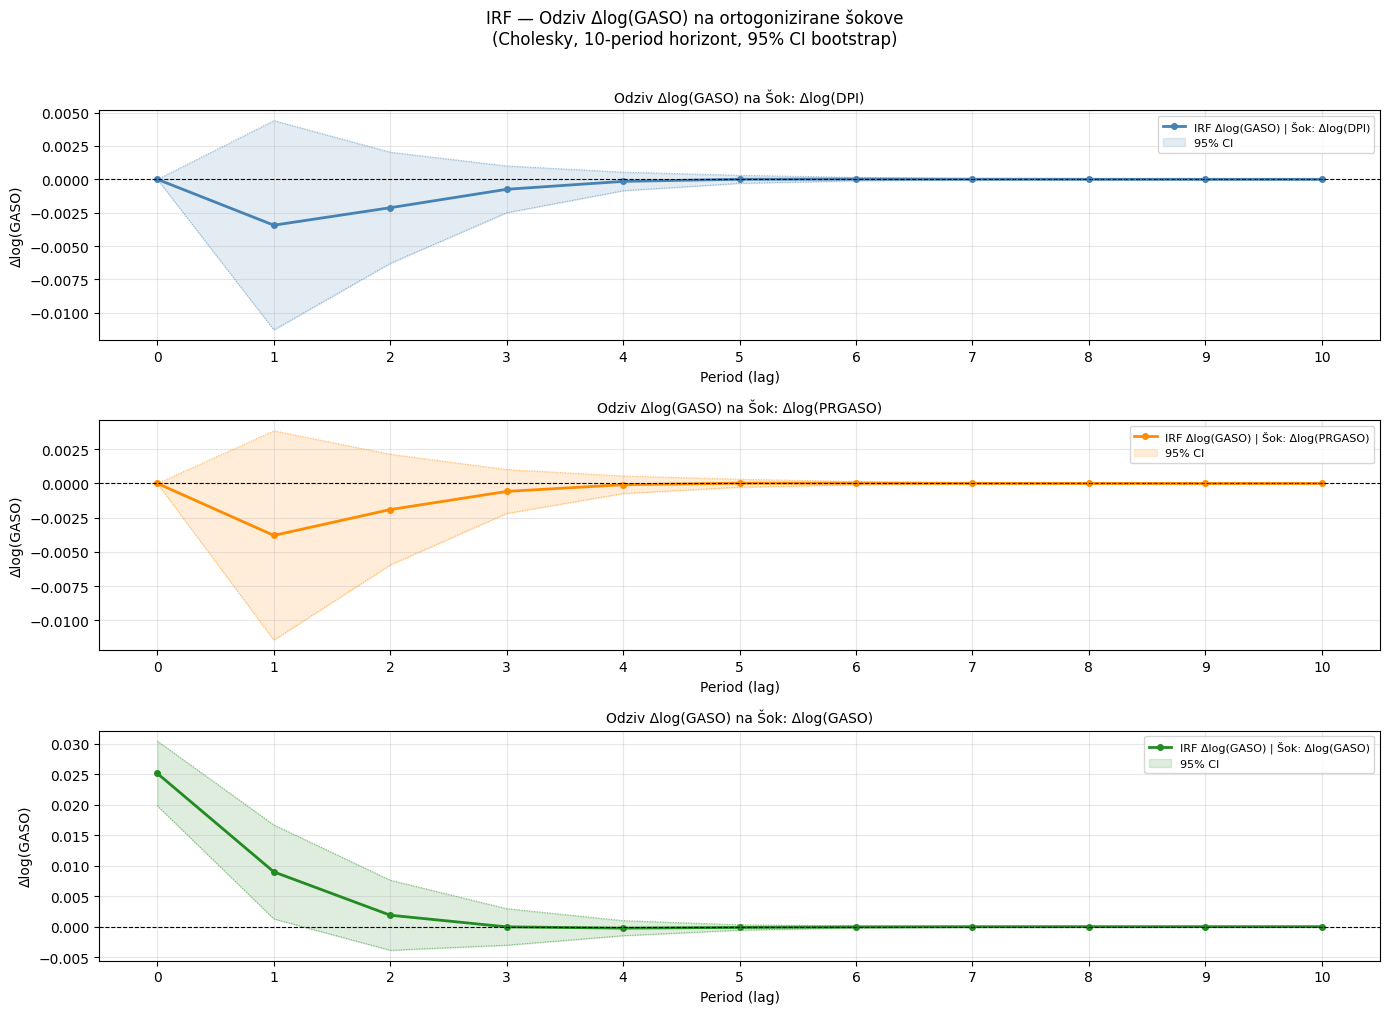


NUMERIČKE VRIJEDNOSTI IRF — Odziv Δlog(GASO) na šokove

  Period    Šok: Δlog(DPI)   Šok: Δlog(PRGASO)   Šok: Δlog(GASO)
  ──────────────────────────────────────────────────────────────
       0          0.000000            0.000000          0.025126
       1         -0.003437           -0.003794          0.008984
       2         -0.002127           -0.001907          0.001882
       3         -0.000747           -0.000583         -0.000030
       4         -0.000155           -0.000092         -0.000234
       5          0.000003            0.000018         -0.000122
       6          0.000020            0.000020         -0.000038
       7          0.000010            0.000009         -0.000007
       8          0.000003            0.000002          0.000001
       9          0.000001            0.000000          0.000001
      10         -0.000000           -0.000000          0.000001

INTERPRETACIJA IRF:
───────────────────
  • Šok u Δlog(DPI) (dohodak):
    Pozitivni šok u DPI tr

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

print("=" * 70)
print("c) FUNKCIJA IMPULSNOG ODZIVA (IRF) — odgovor Δlog(GASO)")
print("=" * 70)

print("""
Funkcija impulsnog odziva (IRF) mjeri kako šok veličine jedne standardne
devijacije u jednoj varijabli utječe na drugu varijablu u budućim periodima.

Specifikacija: Ortogonizirani šokovi (Cholesky dekompozicija)
Horizont: 10 perioda (kvartala/godina)
Varijabla od interesa: Δlog(GASO)

Red Cholesky dekompozicije (od najegzogenije prema najendogenijem):
  1. Δlog(DPI)    — relativno egzogena (dohodak)
  2. Δlog(PRGASO) — djelomično egzogena (relativna cijena)
  3. Δlog(GASO)   — endogena (potrošnja goriva)

Ovaj redoslijed odražava ekonomsku pretpostavku da tekuće promjene dohotka
i cijena utječu na potrošnju goriva, ali ne obrnuto (u kratkom roku).
""")

# ── Izračun IRF ───────────────────────────────────────────────────────────────
irf = var_result.irf(periods=10)
periods = np.arange(0, 11)

# ── IRF za Δlog(GASO): povratna varijabla je d_log_GASO (index 0)
# irf.orth_irfs shape: (periods+1, K, K)
# irf.orth_irfs[:, i, j] = odziv varijable i na šok varijable j
gaso_idx   = var_data.columns.get_loc('d_log_GASO')
dpi_idx    = var_data.columns.get_loc('d_log_DPI')
prgaso_idx = var_data.columns.get_loc('d_log_PRGASO')

irf_gaso_own   = irf.orth_irfs[:, gaso_idx, gaso_idx]   # šok GASO → GASO
irf_gaso_dpi   = irf.orth_irfs[:, gaso_idx, dpi_idx]    # šok DPI → GASO
irf_gaso_price = irf.orth_irfs[:, gaso_idx, prgaso_idx] # šok PRGASO → GASO

# ── Konfidencijalni intervali (bootstrap) ─────────────────────────────────────
irf_ci = irf.cum_effect_stderr(orth=True)   # se, shape (periods, K, K)
# Upotreba irf.plot za automatski grafički prikaz
fig = plt.figure(figsize=(14, 10))
fig.suptitle("IRF — Odziv Δlog(GASO) na ortogonizirane šokove\n(Cholesky, 10-period horizont, 95% CI bootstrap)",
             fontsize=12, y=1.01)

shock_labels  = ['Šok: Δlog(DPI)', 'Šok: Δlog(PRGASO)', 'Šok: Δlog(GASO)']
shock_indices = [dpi_idx, prgaso_idx, gaso_idx]
colors        = ['steelblue', 'darkorange', 'forestgreen']

# ICI vrijednosti generiramo bootstrapom
try:
    irf_ci_low  = irf.orth_irfs - 1.96 * irf.stderr(orth=True)
    irf_ci_high = irf.orth_irfs + 1.96 * irf.stderr(orth=True)
    has_ci = True
except Exception:
    has_ci = False

for idx_plot, (shock_idx, shock_label, color) in enumerate(zip(shock_indices, shock_labels, colors)):
    ax = fig.add_subplot(3, 1, idx_plot + 1)
    impulse_response = irf.orth_irfs[:, gaso_idx, shock_idx]
    ax.plot(periods, impulse_response, color=color, linewidth=2, marker='o', markersize=4,
            label=f'IRF Δlog(GASO) | {shock_label}')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if has_ci:
        ci_l = irf_ci_low[:, gaso_idx, shock_idx]
        ci_h = irf_ci_high[:, gaso_idx, shock_idx]
        ax.fill_between(periods, ci_l, ci_h, alpha=0.15, color=color, label='95% CI')
        ax.plot(periods, ci_l, color=color, linewidth=0.7, linestyle=':', alpha=0.6)
        ax.plot(periods, ci_h, color=color, linewidth=0.7, linestyle=':', alpha=0.6)
    ax.set_title(f'Odziv Δlog(GASO) na {shock_label}', fontsize=10)
    ax.set_xlabel('Period (lag)')
    ax.set_ylabel('Δlog(GASO)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xticks(periods)

plt.tight_layout()
plt.show()

# ── Numerički prikaz IRF vrijednosti ──────────────────────────────────────────
print()
print("=" * 70)
print("NUMERIČKE VRIJEDNOSTI IRF — Odziv Δlog(GASO) na šokove")
print("=" * 70)
print(f"\n  {'Period':>6}  {'Šok: Δlog(DPI)':>16}  {'Šok: Δlog(PRGASO)':>18}  {'Šok: Δlog(GASO)':>16}")
print("  " + "─" * 62)
for t in range(11):
    v1 = irf.orth_irfs[t, gaso_idx, dpi_idx]
    v2 = irf.orth_irfs[t, gaso_idx, prgaso_idx]
    v3 = irf.orth_irfs[t, gaso_idx, gaso_idx]
    print(f"  {t:>6}  {v1:>16.6f}  {v2:>18.6f}  {v3:>16.6f}")

print("""
INTERPRETACIJA IRF:
───────────────────
  • Šok u Δlog(DPI) (dohodak):
    Pozitivni šok u DPI trebao bi povećati potrošnju goriva (GASO).
    Veličina i trajnost odziva odražavaju kratkoročnu dohodovnu elastičnost.

  • Šok u Δlog(PRGASO) (relativna cijena):
    Pozitivni cjenovni šok (porast relativne cijene goriva) trebao bi
    smanjiti potrošnju — odziv bi trebao biti negativan.
    Veličina odražava cjenovnu elastičnost potražnje za gorivom.

  • Šok u sam Δlog(GASO) (vlastiti šok):
    Mjeri inerciju/autoregresivnost potrošnje goriva.
    Brzo opadanje na nulu = nema dugotrajnih učinaka (stacionarnost).
""")
print("=" * 70)


#### d) Dekompozicija varijance (FEVD) za $\Delta\log(GASO)$

FEVD prikazuje koliki dio varijance pogreške prognoze varijable $\Delta\log(GASO)$ dolazi od:
- vlastitih šokova
- šokova u $\Delta\log(DPI)$
- šokova u $\Delta\log(PRGASO)$.


d) DEKOMPOZICIJA VARIJANCE (FEVD) — Δlog(GASO)

Dekompozicija varijance greške prognoze (FEVD) mjeri koliki postotak
varijance greške prognoze varijable Y u horizontu h-perioda možemo
pripisati šokovima u svakoj varijabli sustava.

  Varijabla: Δlog(GASO)
  Horizont:  1 do 10 perioda
  Metoda:    Cholesky ortogonalizacija (isti redoslijed kao za IRF)

  Interpretacija:
  — U periodu 1 sve varijance su zbog vlastitih šokova 
    (po definiciji Cholesky-ja za varijablu na zadnjem mjestu).
  — S dužim horizontom, udio "tuđih" šokova može rasti 
    ako su varijable međusobno povezane.

──────────────────────────────────────────────────────────────────────
  Udio u varijanci prognostičke greške Δlog(GASO) (%)
──────────────────────────────────────────────────────────────────────

    Horizont     Δlog(DPI)    Δlog(PRGASO)    Δlog(GASO)    Ukupno
  ──────────────────────────────────────────────────────────────
           1          0.00            0.00        100.00    100.00
           2  

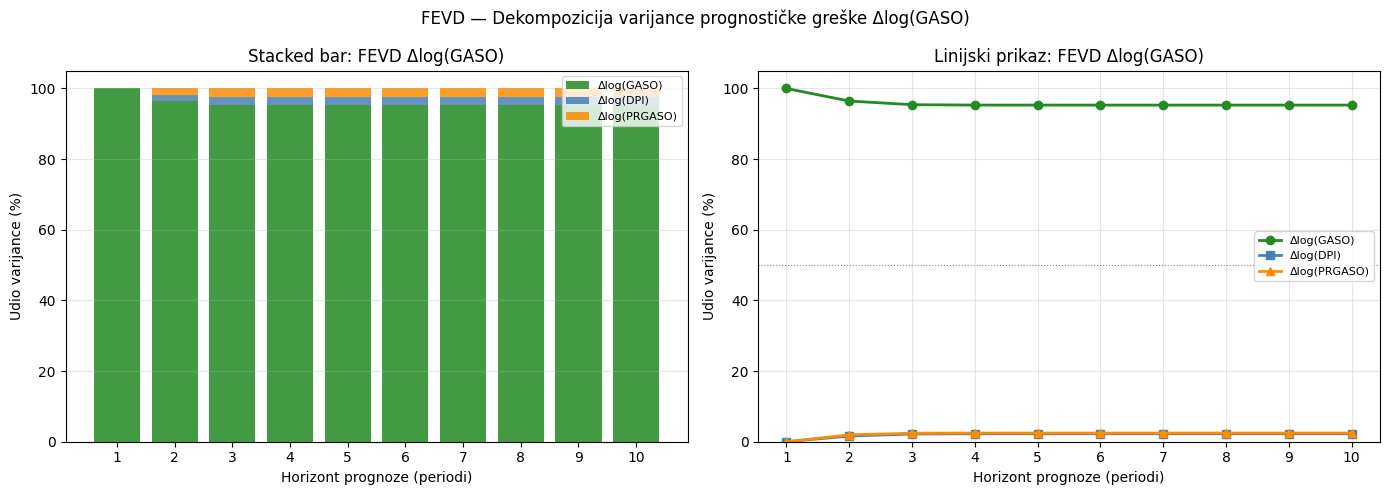

ZAKLJUČAK — FEVD analize

  Horizont 1:
    Δlog(GASO)   = 100.00 %  (vlastiti šok)
    Δlog(DPI)    = 0.00 %  (šok dohotka)
    Δlog(PRGASO) = 0.00 %  (šok relativne cijene)

  Horizont 10:
    Δlog(GASO)   = 95.30 %  (vlastiti šok)
    Δlog(DPI)    = 2.25 %  (šok dohotka)
    Δlog(PRGASO) = 2.45 %  (šok relativne cijene)

  Interpretacija:
  — Kratkoročno (horizont 1): Δlog(GASO) vlastiti šok dominira s
    100.0% varijance prognostičke greške (karakteristično za
    Cholesky s GASO na zadnjem mjestu u redoslijedu).

  — Udio Δlog(DPI) u varijanci Δlog(GASO): raste s horizontom
    (0.0% u h=1 → 2.3% u h=10).

  — Udio Δlog(PRGASO) u varijanci Δlog(GASO): raste s horizontom
    (0.0% u h=1 → 2.4% u h=10).

  — Udio vlastitih šokova Δlog(GASO): pada s horizontom
    (100.0% u h=1 → 95.3% u h=10).

  — Ukupno šokovi dohotka i cijene objašnjavaju ~4.7% varijance
    Δlog(GASO) u horizontu 10 — što je relativno malo i upućuje na to da
    potrošnja goriva u kratkom roku dominantno slijed

In [19]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("d) DEKOMPOZICIJA VARIJANCE (FEVD) — Δlog(GASO)")
print("=" * 70)

print("""
Dekompozicija varijance greške prognoze (FEVD) mjeri koliki postotak
varijance greške prognoze varijable Y u horizontu h-perioda možemo
pripisati šokovima u svakoj varijabli sustava.

  Varijabla: Δlog(GASO)
  Horizont:  1 do 10 perioda
  Metoda:    Cholesky ortogonalizacija (isti redoslijed kao za IRF)
  
  Interpretacija:
  — U periodu 1 sve varijance su zbog vlastitih šokova 
    (po definiciji Cholesky-ja za varijablu na zadnjem mjestu).
  — S dužim horizontom, udio "tuđih" šokova može rasti 
    ako su varijable međusobno povezane.
""")

# ── Izračun FEVD ──────────────────────────────────────────────────────────────
n_periods = 10
fevd_result = var_result.fevd(periods=n_periods)
fevd_decomp = fevd_result.decomp   # shape: (neqs, periods, neqs) in statsmodels
# Shape (3, 10, 3): dim0=neqs(explained var), dim1=periods(0-based), dim2=neqs(shock source)

gaso_idx   = var_data.columns.get_loc('d_log_GASO')
dpi_idx    = var_data.columns.get_loc('d_log_DPI')
prgaso_idx = var_data.columns.get_loc('d_log_PRGASO')

# ── Numerička tablica ──────────────────────────────────────────────────────────
print("─" * 70)
print(f"  Udio u varijanci prognostičke greške Δlog(GASO) (%)")
print("─" * 70)
print(f"\n  {'Horizont':>10}  {'Δlog(DPI)':>12}  {'Δlog(PRGASO)':>14}  {'Δlog(GASO)':>12}  {'Ukupno':>8}")
print("  " + "─" * 62)

fevd_table = []
s = fevd_decomp.shape

for h in range(1, n_periods + 1):
    if s[0] == 3 and s[2] == 3:
        # (neqs, periods, neqs): dim0=explained var, dim1=period (0-based), dim2=shock
        row_dpi    = float(fevd_decomp[gaso_idx, h - 1, dpi_idx])
        row_prgaso = float(fevd_decomp[gaso_idx, h - 1, prgaso_idx])
        row_gaso   = float(fevd_decomp[gaso_idx, h - 1, gaso_idx])
    else:
        # (periods, neqs, neqs): dim0=period (0-based), dim1=explained, dim2=shock
        row_dpi    = float(fevd_decomp[h - 1, gaso_idx, dpi_idx])
        row_prgaso = float(fevd_decomp[h - 1, gaso_idx, prgaso_idx])
        row_gaso   = float(fevd_decomp[h - 1, gaso_idx, gaso_idx])

    share_dpi    = row_dpi    * 100
    share_prgaso = row_prgaso * 100
    share_gaso   = row_gaso   * 100
    total        = share_dpi + share_prgaso + share_gaso
    fevd_table.append((h, share_dpi, share_prgaso, share_gaso))
    print(f"  {h:>10}  {share_dpi:>12.2f}  {share_prgaso:>14.2f}  {share_gaso:>12.2f}  {total:>8.2f}")

print()

# ── Grafički prikaz — složeni stupčasti graf (stacked bar) ─────────────────────
horizons     = [r[0] for r in fevd_table]
share_dpi_v  = [r[1] for r in fevd_table]
share_pr_v   = [r[2] for r in fevd_table]
share_go_v   = [r[3] for r in fevd_table]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FEVD — Dekompozicija varijance prognostičke greške Δlog(GASO)", fontsize=12)

# -- Lijeva os: složeni stupčasti (stacked bar)
ax1 = axes[0]
ax1.bar(horizons, share_go_v,  label='Δlog(GASO)',    color='forestgreen', alpha=0.85)
ax1.bar(horizons, share_dpi_v, bottom=share_go_v,     label='Δlog(DPI)',    color='steelblue', alpha=0.85)
bottom2 = [a + b for a, b in zip(share_go_v, share_dpi_v)]
ax1.bar(horizons, share_pr_v,  bottom=bottom2,         label='Δlog(PRGASO)', color='darkorange', alpha=0.85)
ax1.set_xlabel('Horizont prognoze (periodi)')
ax1.set_ylabel('Udio varijance (%)')
ax1.set_title('Stacked bar: FEVD Δlog(GASO)')
ax1.set_xticks(horizons)
ax1.set_ylim(0, 105)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# -- Desna os: linijski prikaz
ax2 = axes[1]
ax2.plot(horizons, share_go_v,  marker='o', color='forestgreen', linewidth=2, label='Δlog(GASO)')
ax2.plot(horizons, share_dpi_v, marker='s', color='steelblue',   linewidth=2, label='Δlog(DPI)')
ax2.plot(horizons, share_pr_v,  marker='^', color='darkorange',  linewidth=2, label='Δlog(PRGASO)')
ax2.axhline(50, color='gray', linestyle=':', linewidth=0.8)
ax2.set_xlabel('Horizont prognoze (periodi)')
ax2.set_ylabel('Udio varijance (%)')
ax2.set_title('Linijski prikaz: FEVD Δlog(GASO)')
ax2.set_xticks(horizons)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Zaključak ─────────────────────────────────────────────────────────────────
h1_gaso  = fevd_table[0][3]
h1_dpi   = fevd_table[0][1]
h1_pr    = fevd_table[0][2]
h10_gaso = fevd_table[9][3]
h10_dpi  = fevd_table[9][1]
h10_pr   = fevd_table[9][2]

trend_dpi  = "raste" if h10_dpi  > h1_dpi  else "pada/stabilno"
trend_pr   = "raste" if h10_pr   > h1_pr   else "pada/stabilno"
trend_gaso = "pada"  if h10_gaso < h1_gaso else "raste/stabilno"

print("=" * 70)
print("ZAKLJUČAK — FEVD analize")
print("=" * 70)
print(f"""
  Horizont 1:
    Δlog(GASO)   = {h1_gaso:.2f} %  (vlastiti šok)
    Δlog(DPI)    = {h1_dpi:.2f} %  (šok dohotka)
    Δlog(PRGASO) = {h1_pr:.2f} %  (šok relativne cijene)

  Horizont 10:
    Δlog(GASO)   = {h10_gaso:.2f} %  (vlastiti šok)
    Δlog(DPI)    = {h10_dpi:.2f} %  (šok dohotka)
    Δlog(PRGASO) = {h10_pr:.2f} %  (šok relativne cijene)

  Interpretacija:
  — Kratkoročno (horizont 1): Δlog(GASO) vlastiti šok dominira s
    {h1_gaso:.1f}% varijance prognostičke greške (karakteristično za
    Cholesky s GASO na zadnjem mjestu u redoslijedu).

  — Udio Δlog(DPI) u varijanci Δlog(GASO): {trend_dpi} s horizontom
    ({h1_dpi:.1f}% u h=1 → {h10_dpi:.1f}% u h=10).

  — Udio Δlog(PRGASO) u varijanci Δlog(GASO): {trend_pr} s horizontom
    ({h1_pr:.1f}% u h=1 → {h10_pr:.1f}% u h=10).

  — Udio vlastitih šokova Δlog(GASO): {trend_gaso} s horizontom
    ({h1_gaso:.1f}% u h=1 → {h10_gaso:.1f}% u h=10).

  — Ukupno šokovi dohotka i cijene objašnjavaju ~{h10_dpi + h10_pr:.1f}% varijance
    Δlog(GASO) u horizontu 10 — što je relativno malo i upućuje na to da
    potrošnja goriva u kratkom roku dominantno slijedi vlastitu dinamiku.
    Ovo je konzistentno s malom veličinom VAR(1) koeficijenata tih varijabli
    u jednadžbi Δlog(GASO).

  — NAPOMENA: FEVD ovisi o odabiru Cholesky redoslijeda pa se
    rezultati mogu razlikovati pri drugačijem redoslijedu varijabli.
""")
print("=" * 70)
